In [3]:
import pandas as pd

file_path = "D:\\CSNet-IDA\\data\\raw\\KDDTrain+.txt"
df = pd.read_csv(file_path, header = None)

print(df.shape)



(125973, 43)


In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [5]:
column_names = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty"
]

df.columns = column_names

print(df.columns.tolist())

['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty']


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [7]:
df["label"].value_counts()


label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

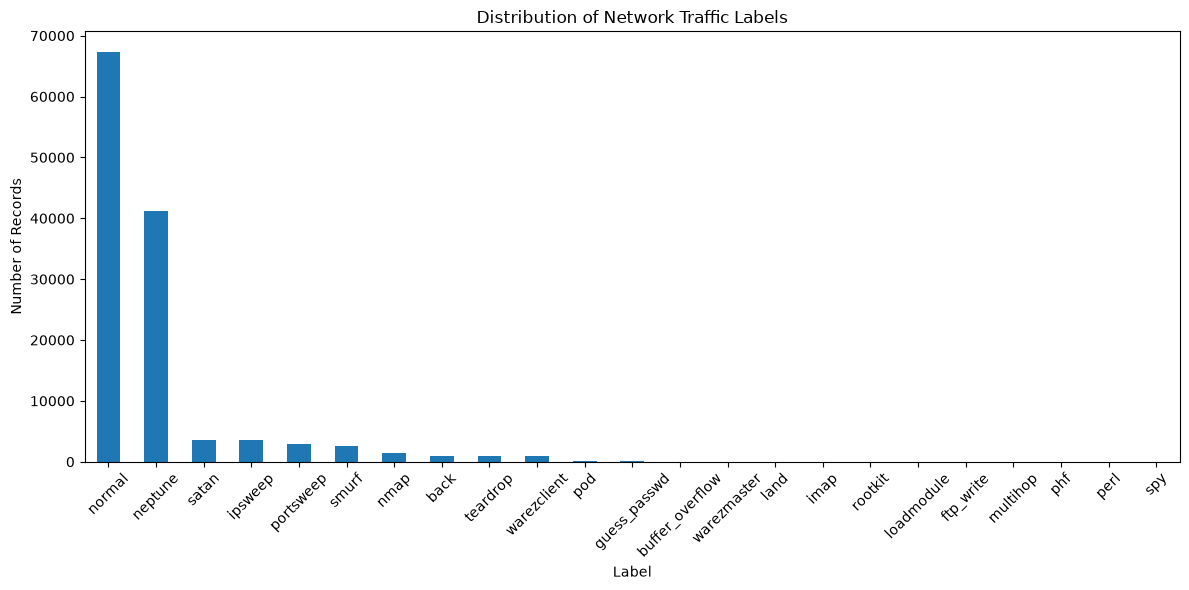

In [8]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar", figsize=(12, 6))

plt.title("Distribution of Network Traffic Labels")
plt.xlabel("Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
attack_categories = {
    "DoS": [
        "back", "land", "neptune", "pod", "smurf", "teardrop"
    ],
    
    "Probe": [
        "ipsweep", "nmap", "portsweep", "satan"
    ],
    
    "R2L": [
        "ftp_write", "guess_passwd", "imap", "multihop",
        "phf", "spy", "warezclient", "warezmaster"
    ],
    
    "U2R": [
        "buffer_overflow", "loadmodule", "perl", "rootkit"
    ]
}

In [10]:
label_to_family = {}

for family, labels in attack_categories.items():
    for label in labels:
        label_to_family[label] = family

label_to_family["normal"] = "Normal"

df["attack_family"] = df["label"].map(label_to_family)

print(df["attack_family"].value_counts())

attack_family
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [11]:
print(df["attack_family"].isna().sum())

0


In [12]:
print("protocol_type:", df["protocol_type"].nunique())
print("service:", df["service"].nunique())
print("flag:", df["flag"].nunique())

protocol_type: 3
service: 70
flag: 11


In [13]:
print("Protocol types:")
print(df["protocol_type"].unique())

print("\nFlags:")
print(df["flag"].unique())

Protocol types:
<StringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str

Flags:
<StringArray>
['SF', 'S0', 'REJ', 'RSTR', 'SH', 'RSTO', 'S1', 'RSTOS0', 'S3', 'S2', 'OTH']
Length: 11, dtype: str


In [14]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(
    df[["protocol_type", "service", "flag"]]
)

print("Original categorical columns:", 3)
print("Encoded columns:", encoded.shape[1])


Original categorical columns: 3
Encoded columns: 84


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


In [16]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

constant_features = [
    col for col in numeric_columns
    if df[col].nunique() <= 1
]

print("Constant features:")
print(constant_features)

Constant features:
['num_outbound_cmds']


In [17]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [18]:
df["stage1_target"] = (df["label"] != "normal").astype(int)

print(df["stage1_target"].value_counts())

stage1_target
0    67343
1    58630
Name: count, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["label", "attack_family", "stage1_target", "difficulty"])
y = df["stage1_target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

Training set: (100778, 41)
Testing set: (25195, 41)

Training target:
stage1_target
0    53874
1    46904
Name: count, dtype: int64

Testing target:
stage1_target
0    13469
1    11726
Name: count, dtype: int64


In [20]:
categorical_features = ["protocol_type", "service", "flag"]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Categorical features:
['protocol_type', 'service', 'flag']

Number of numerical features: 38
Number of categorical features: 3


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['protocol_type', 'service', 'flag']),
                                ('numerical', 'passthrough',
                                 ['duration', 'src_bytes', 'dst_bytes', 'land',
                                  'wrong_fragment', 'urgent', 'hot',
                                  'num_failed_logins', 'logged_in',
                                  'num_compromised', 'root_shell',
                                  'su_attempted', 'num_root',
                                  'num_file_creations', 'num_shells',
                                  'num_access_files', 'num_outbound_cmds',
                                  'is_host_login', 'is_guest_login', 'count',
                                  'srv_count', 'serror_rate', 'srv_serror_rate',
                                  'rerror_rate', 'srv_rerror_rate',
                            

In [22]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (100778, 121)
Processed testing shape: (25195, 121)


In [23]:
X = df.drop(
    columns=[
        "label",
        "attack_family",
        "stage1_target",
        "difficulty",
        "num_outbound_cmds"
    ]
)

y = df["stage1_target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (125973, 40)
y shape: (125973,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (100778, 40)
Testing set: (25195, 40)


In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["protocol_type", "service", "flag"]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 37
Categorical features: 3


In [26]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (100778, 120)
Processed testing shape: (25195, 120)


In [27]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train_processed, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


c:\Users\sumai\miniconda3\envs\data-science\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
print(X_train[numerical_features][["duration", "src_bytes", "dst_bytes"]].describe().T)

              count          mean           std  min  25%   50%    75%  \
duration   100778.0    289.422553  2.612980e+03  0.0  0.0   0.0    0.0   
src_bytes  100778.0  40066.468475  5.384804e+06  0.0  0.0  44.0  275.0   
dst_bytes  100778.0  23753.821886  4.495654e+06  0.0  0.0   0.0  513.0   

                    max  
duration   4.290800e+04  
src_bytes  1.379964e+09  
dst_bytes  1.309937e+09  


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

print(preprocessor_scaled)

ColumnTransformer(transformers=[('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['protocol_type', 'service', 'flag']),
                                ('numerical', StandardScaler(),
                                 ['duration', 'src_bytes', 'dst_bytes', 'land',
                                  'wrong_fragment', 'urgent', 'hot',
                                  'num_failed_logins', 'logged_in',
                                  'num_compromised', 'root_shell',
                                  'su_attempted', 'num_root',
                                  'num_file_creations', 'num_shells',
                                  'num_access_files', 'is_host_login',
                                  'is_guest_login', 'count', 'srv_count',
                                  'serror_rate', 'srv_serror_rate',
                                  'rerror_rate', 'srv_rerror_rate',
                                  'same_srv_ra

In [30]:
preprocessor_scaled.fit(X_train)

X_train_scaled = preprocessor_scaled.transform(X_train)
X_test_scaled = preprocessor_scaled.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (100778, 120)
Scaled testing shape: (25195, 120)


In [31]:
from sklearn.linear_model import LogisticRegression

scaled_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

scaled_baseline.fit(X_train_scaled, y_train)

print("Scaled baseline trained successfully.")

Scaled baseline trained successfully.


In [32]:
y_pred = scaled_baseline.predict(X_test_scaled)

print("Predictions generated:", len(y_pred))
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated: 25195
First 20 predictions:
[1 0 1 1 0 0 0 0 1 1 0 1 1 0 0 0 0 0 1 0]


In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9719388767612621


In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[13196   273]
 [  434 11292]]


In [35]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Attack"]
))

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97     13469
      Attack       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195



In [36]:
results = X_test.copy()

results["actual"] = y_test
results["predicted"] = y_pred
results["label"] = df.loc[X_test.index, "label"]
results["attack_family"] = df.loc[X_test.index, "attack_family"]

missed_attacks = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print("Total missed attacks:", len(missed_attacks))

print("\nMissed attacks by family:")
print(missed_attacks["attack_family"].value_counts())

print("\nMissed attacks by original label:")
print(missed_attacks["label"].value_counts())

Total missed attacks: 434

Missed attacks by family:
attack_family
DoS      166
R2L      151
Probe    115
U2R        2
Name: count, dtype: int64

Missed attacks by original label:
label
back               147
warezclient        144
satan               80
ipsweep             25
neptune             15
portsweep            5
nmap                 5
land                 4
multihop             3
buffer_overflow      2
ftp_write            2
phf                  1
spy                  1
Name: count, dtype: int64


In [37]:
print("Actual attack families in test set:")
print(
    results[results["actual"] == 1]["attack_family"]
    .value_counts()
)

print("\nMiss rate by attack family:")
print(
    missed_attacks["attack_family"].value_counts()
    /
    results[results["actual"] == 1]["attack_family"].value_counts()
)

Actual attack families in test set:
attack_family
DoS      9105
Probe    2389
R2L       226
U2R         6
Name: count, dtype: int64

Miss rate by attack family:
attack_family
DoS      0.018232
Probe    0.048137
R2L      0.668142
U2R      0.333333
Name: count, dtype: float64


In [38]:
print("R2L distribution in test set:")
print(
    results[results["attack_family"] == "R2L"]["label"].value_counts()
)

print("\nR2L missed by label:")
print(
    missed_attacks[missed_attacks["attack_family"] == "R2L"]["label"].value_counts()
)

R2L distribution in test set:
label
warezclient     198
guess_passwd     13
warezmaster       5
multihop          4
ftp_write         2
imap              2
phf               1
spy               1
Name: count, dtype: int64

R2L missed by label:
label
warezclient    144
multihop         3
ftp_write        2
phf              1
spy              1
Name: count, dtype: int64


In [39]:
print("R2L samples in training set:")
print(
    df.loc[X_train.index, "attack_family"].value_counts()
)

R2L samples in training set:
attack_family
Normal    53874
DoS       36822
Probe      9267
R2L         769
U2R          46
Name: count, dtype: int64


In [40]:
r2l_train = df.loc[X_train.index, "attack_family"].eq("R2L").sum()
normal_train = df.loc[X_train.index, "attack_family"].eq("Normal").sum()

print("Normal training samples:", normal_train)
print("R2L training samples:", r2l_train)
print("Normal : R2L ratio:", normal_train / r2l_train)

Normal training samples: 53874
R2L training samples: 769
Normal : R2L ratio: 70.05721716514954


In [41]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(X_train_scaled, y_train)

print("Balanced model trained successfully.")

Balanced model trained successfully.


In [42]:
balanced_pred = balanced_model.predict(X_test_scaled)

print("Predictions generated:", len(balanced_pred))

Predictions generated: 25195


In [43]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    balanced_pred,
    target_names=["Normal", "Attack"]
))

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97     13469
      Attack       0.97      0.97      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195



In [44]:
balanced_results = X_test.copy()

balanced_results["actual"] = y_test
balanced_results["predicted"] = balanced_pred
balanced_results["label"] = df.loc[X_test.index, "label"]
balanced_results["attack_family"] = df.loc[
    X_test.index, "attack_family"
]

balanced_missed = balanced_results[
    (balanced_results["actual"] == 1) &
    (balanced_results["predicted"] == 0)
]

print("Total missed attacks:", len(balanced_missed))

print("\nMissed attacks by family:")
print(balanced_missed["attack_family"].value_counts())

print("\nMiss rate by family:")
print(
    balanced_missed["attack_family"].value_counts()
    /
    balanced_results[
        balanced_results["actual"] == 1
    ]["attack_family"].value_counts()
)

Total missed attacks: 400

Missed attacks by family:
attack_family
DoS      159
R2L      130
Probe    109
U2R        2
Name: count, dtype: int64

Miss rate by family:
attack_family
DoS      0.017463
Probe    0.045626
R2L      0.575221
U2R      0.333333
Name: count, dtype: float64


In [45]:
r2l_data = df.loc[
    df["attack_family"] == "R2L",
    numerical_features
]

normal_data = df.loc[
    df["attack_family"] == "Normal",
    numerical_features
]

comparison = pd.DataFrame({
    "Normal_mean": normal_data.mean(),
    "R2L_mean": r2l_data.mean()
})

comparison["difference"] = (
    comparison["R2L_mean"] - comparison["Normal_mean"]
)

print(comparison.sort_values(
    "difference",
    key=abs,
    ascending=False
).head(15))

                              Normal_mean       R2L_mean     difference
src_bytes                    13133.279331  307727.300503  294594.021171
dst_bytes                     4329.685223   81822.026131   77492.340907
duration                       168.587396     633.417085     464.829690
dst_host_srv_count             190.285761      42.440201    -147.845560
dst_host_count                 147.431923      89.037186     -58.394737
srv_count                       27.685654       2.457286     -25.228368
count                           22.517945       1.297487     -21.220458
hot                              0.230655       8.334673       8.104018
dst_host_same_src_port_rate      0.121726       0.596915       0.475189
num_root                         0.562924       0.111558      -0.451366
num_compromised                  0.507076       0.077387      -0.429689
is_guest_login                   0.012963       0.314573       0.301609
logged_in                        0.710646       0.913568       0

In [46]:
comparison_median = pd.DataFrame({
    "Normal_median": normal_data.median(),
    "R2L_median": r2l_data.median()
})

comparison_median["difference"] = (
    comparison_median["R2L_median"]
    - comparison_median["Normal_median"]
)

print(
    comparison_median.sort_values(
        "difference",
        key=abs,
        ascending=False
    ).head(15)
)

                             Normal_median  R2L_median  difference
dst_bytes                           379.00        0.00     -379.00
dst_host_srv_count                  255.00       35.00     -220.00
dst_host_count                      156.00       10.00     -146.00
src_bytes                           233.00      334.00      101.00
srv_count                             5.00        1.00       -4.00
count                                 4.00        1.00       -3.00
dst_host_same_src_port_rate           0.01        1.00        0.99
dst_host_srv_diff_host_rate           0.00        0.07        0.07
duration                              0.00        0.00        0.00
wrong_fragment                        0.00        0.00        0.00
land                                  0.00        0.00        0.00
urgent                                0.00        0.00        0.00
hot                                   0.00        0.00        0.00
num_root                              0.00        0.00        

In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

preprocessor_unscaled.fit(X_train)

X_train_unscaled = preprocessor_unscaled.transform(X_train)
X_test_unscaled = preprocessor_unscaled.transform(X_test)

print("Training shape:", X_train_unscaled.shape)
print("Testing shape:", X_test_unscaled.shape)

Training shape: (100778, 120)
Testing shape: (25195, 120)


In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_unscaled, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [49]:
rf_pred = rf_model.predict(X_test_unscaled)

print("Predictions generated:", len(rf_pred))

Predictions generated: 25195


In [50]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred,
    target_names=["Normal", "Attack"]
))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



In [51]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[13463     6]
 [   18 11708]]


In [52]:
import pandas as pd

feature_names = preprocessor_unscaled.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

print(feature_importance.head(20))

                                    feature  importance
84                     numerical__src_bytes    0.143537
85                     numerical__dst_bytes    0.105221
107                numerical__same_srv_rate    0.062301
108                numerical__diff_srv_rate    0.059591
113       numerical__dst_host_diff_srv_rate    0.057981
81                     categorical__flag_SF    0.049593
117     numerical__dst_host_srv_serror_rate    0.041592
101                        numerical__count    0.041380
91                     numerical__logged_in    0.034210
77                     categorical__flag_S0    0.033409
116         numerical__dst_host_serror_rate    0.030749
111           numerical__dst_host_srv_count    0.029944
112       numerical__dst_host_same_srv_rate    0.026998
114  numerical__dst_host_same_src_port_rate    0.023388
115  numerical__dst_host_srv_diff_host_rate    0.022910
51             categorical__service_private    0.019027
18               categorical__service_ecr_i    0

In [53]:
print("difficulty in numerical features:",
      "difficulty" in numerical_features)

print("label in numerical features:",
      "label" in numerical_features)

print("stage1_target in numerical features:",
      "stage1_target" in numerical_features)

print("attack_family in numerical features:",
      "attack_family" in numerical_features)

difficulty in numerical features: False
label in numerical features: False
stage1_target in numerical features: False
attack_family in numerical features: False


In [54]:
train_hashes = set(map(tuple, X_train))
test_hashes = set(map(tuple, X_test))

overlap = train_hashes.intersection(test_hashes)

print("Exact duplicate feature rows shared by train and test:", len(overlap))
print("Total training rows:", len(X_train))
print("Total testing rows:", len(X_test))

Exact duplicate feature rows shared by train and test: 40
Total training rows: 100778
Total testing rows: 25195


In [55]:
train_hashes = set(map(tuple, X_train))
test_hashes = set(map(tuple, X_test))

overlap = train_hashes.intersection(test_hashes)

print("Exact duplicate feature rows shared by train and test:", len(overlap))
print("Total training rows:", len(X_train))
print("Total testing rows:", len(X_test))

Exact duplicate feature rows shared by train and test: 40
Total training rows: 100778
Total testing rows: 25195


In [57]:
train_df = X_train.copy()
test_df = X_test.copy()

train_df["label"] = y_train.values
test_df["label"] = y_test.values

feature_cols = X_train.columns.tolist()

merged = test_df.merge(
    train_df,
    on=feature_cols,
    suffixes=("_test", "_train")
)

print("Matching rows found:", len(merged))
print("Matching rows with same label:", (merged["label_test"] == merged["label_train"]).sum())
print("Matching rows with different label:", (merged["label_test"] != merged["label_train"]).sum())

Matching rows found: 6
Matching rows with same label: 4
Matching rows with different label: 2


In [58]:
from sklearn.metrics import accuracy_score

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Correct predictions:", (y_test.values == y_pred).sum())
print("Total predictions:", len(y_test))
print("Incorrect predictions:", (y_test.values != y_pred).sum())

c:\Users\sumai\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


ValueError: could not convert string to float: 'tcp'

In [59]:
print(type(X_train))
print(type(X_test))
print(type(rf_model))
print(rf_model.n_features_in_)
print(X_train.shape)
print(X_test.shape)

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'sklearn.ensemble._forest.RandomForestClassifier'>
120
(100778, 40)
(25195, 40)


In [60]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("RF expected features:", rf_model.n_features_in_)
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

X_train shape: (100778, 40)
X_test shape: (25195, 40)
RF expected features: 120
Numerical features: 37
Categorical features: 3


In [61]:
print([name for name in globals() if "X_" in name or "encoder" in name.lower() or "transform" in name.lower()])

['OneHotEncoder', 'encoder', 'X_train', 'X_test', 'ColumnTransformer', 'X_train_processed', 'X_test_processed', 'X_train_scaled', 'X_test_scaled', 'X_train_unscaled', 'X_test_unscaled']


In [62]:
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)
print("RF expected features:", rf_model.n_features_in_)

Processed train shape: (100778, 120)
Processed test shape: (25195, 120)
RF expected features: 120


In [63]:
from sklearn.metrics import accuracy_score

y_pred = rf_model.predict(X_test_processed)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Correct predictions:", (y_test.values == y_pred).sum())
print("Total predictions:", len(y_test))
print("Incorrect predictions:", (y_test.values != y_pred).sum())

Accuracy: 0.999047430045644
Correct predictions: 25171
Total predictions: 25195
Incorrect predictions: 24


In [64]:
misclassified = y_test.values != y_pred

print("Misclassified:", misclassified.sum())
print("Actual labels:", y_test.values[misclassified])
print("Predicted labels:", y_pred[misclassified])


Misclassified: 24
Actual labels: [1 1 1 1 0 1 1 0 0 1 1 0 0 1 0 1 1 1 1 1 1 1 1 1]
Predicted labels: [0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0]


In [65]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[13463     6]
 [   18 11708]]


In [66]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True))

Training class distribution:
stage1_target
0    53874
1    46904
Name: count, dtype: int64

Testing class distribution:
stage1_target
0    13469
1    11726
Name: count, dtype: int64

Training class proportions:
stage1_target
0    0.534581
1    0.465419
Name: proportion, dtype: float64

Testing class proportions:
stage1_target
0    0.53459
1    0.46541
Name: proportion, dtype: float64


In [68]:
print([name for name in globals() if hasattr(globals()[name], "columns") and "attack_family" in globals()[name].columns])

['df', 'results', 'missed_attacks', 'balanced_results', 'balanced_missed']


In [69]:
print(df.shape)
print(df.columns.tolist())
print(df[["attack_family", "stage1_target"]].head())

(125973, 45)
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty', 'attack_family', 'stage1_target']
  attack_family  stage1_target
0        Normal              0
1        Normal              0
2           DoS              1
3        Normal              0
4        Normal              0


In [70]:
print("X_train index type:", type(X_train.index))
print("X_test index type:", type(X_test.index))

print("First X_train indices:", X_train.index[:10].tolist())
print("First X_test indices:", X_test.index[:10].tolist())

print("df indices:", df.index[:10].tolist())

X_train index type: <class 'pandas.Index'>
X_test index type: <class 'pandas.Index'>
First X_train indices: [23630, 39958, 15456, 169, 14833, 78741, 91391, 64373, 5745, 64826]
First X_test indices: [77971, 28221, 18104, 11281, 8545, 51714, 1696, 51570, 34232, 21845]
df indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [71]:
train_families = df.loc[X_train.index, "attack_family"]
test_families = df.loc[X_test.index, "attack_family"]

print("Training attack families:")
print(train_families.value_counts())

print("\nTesting attack families:")
print(test_families.value_counts())

Training attack families:
attack_family
Normal    53874
DoS       36822
Probe      9267
R2L         769
U2R          46
Name: count, dtype: int64

Testing attack families:
attack_family
Normal    13469
DoS        9105
Probe      2389
R2L         226
U2R           6
Name: count, dtype: int64


In [72]:
print("Training attack-family proportions:")
print(train_families.value_counts(normalize=True))

print("\nTesting attack-family proportions:")
print(test_families.value_counts(normalize=True))

Training attack-family proportions:
attack_family
Normal    0.534581
DoS       0.365377
Probe     0.091955
R2L       0.007631
U2R       0.000456
Name: proportion, dtype: float64

Testing attack-family proportions:
attack_family
Normal    0.534590
DoS       0.361381
Probe     0.094820
R2L       0.008970
U2R       0.000238
Name: proportion, dtype: float64


In [73]:
misclassified_indices = X_test.index[y_test.values != y_pred]

misclassified_families = df.loc[misclassified_indices, "attack_family"]

print(misclassified_families.value_counts())

attack_family
R2L       10
Probe      7
Normal     6
DoS        1
Name: count, dtype: int64


In [74]:
print(df.loc[misclassified_indices, ["attack_family", "label", "stage1_target"]])

       attack_family         label  stage1_target
66013          Probe     portsweep              1
10012          Probe          nmap              1
1143             DoS           pod              1
26872            R2L      multihop              1
21323         Normal        normal              0
6004           Probe         satan              1
56279            R2L   warezclient              1
36099         Normal        normal              0
62345         Normal        normal              0
72596          Probe     portsweep              1
64980          Probe     portsweep              1
99025         Normal        normal              0
89291         Normal        normal              0
52037            R2L   warezclient              1
54374         Normal        normal              0
59000            R2L     ftp_write              1
101346           R2L  guess_passwd              1
75944            R2L   warezclient              1
120844         Probe     portsweep              1


In [75]:
train_features = X_train_processed
test_features = X_test_processed

train_feature_tuples = set(map(tuple, train_features))
test_feature_tuples = list(map(tuple, test_features))

duplicate_test_rows = sum(
    row in train_feature_tuples for row in test_feature_tuples
)

print("Test rows whose exact feature vector appears in training:", duplicate_test_rows)
print("Total test rows:", len(test_features))
print("Percentage of test rows duplicated in training:",
      duplicate_test_rows / len(test_features) * 100)

Test rows whose exact feature vector appears in training: 5
Total test rows: 25195
Percentage of test rows duplicated in training: 0.019845207382417147


In [76]:
print([name for name in globals() if "log" in name.lower() or "lr" in name.lower()])

['LogisticRegression']


['LogisticRegression']


In [78]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [79]:
from sklearn.metrics import accuracy_score

lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Correct predictions:", (y_test.values == lr_pred).sum())
print("Total predictions:", len(y_test))
print("Incorrect predictions:", (y_test.values != lr_pred).sum())

Logistic Regression Accuracy: 0.9719388767612621
Correct predictions: 24488
Total predictions: 25195
Incorrect predictions: 707


In [80]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


rf_pred = rf_model.predict(X_test_processed)
lr_pred = lr_model.predict(X_test_scaled)

# Probability scores for ROC-AUC
rf_prob = rf_model.predict_proba(X_test_processed)[:, 1]
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

print(f"Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, rf_prob):.4f}")



print("\n" + "=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

print(f"Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"Recall:    {recall_score(y_test, lr_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, lr_prob):.4f}")

RANDOM FOREST

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix:
[[13463     6]
 [   18 11708]]
Precision: 0.9995
Recall:    0.9985
F1-Score:  0.9990
ROC-AUC:   1.0000

LOGISTIC REGRESSION

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     13469
           1       0.98      0.96      0.97     11726

    accuracy                           0.97     25195
   macro avg       0.97      0.97      0.97     25195
weighted avg       0.97      0.97      0.97     25195

Confusion Matrix:
[[13196   273]
 [  434 11292]]
Precision: 0.9764
Recall:    0.9630
F1-Score:  0.9696
ROC-AUC:   0.9964


In [81]:

test_attack_families = df.loc[X_test.index, "attack_family"]

rf_pred = rf_model.predict(X_test_processed)

print("Random Forest predictions by attack family:\n")

results = pd.DataFrame({
    "attack_family": test_attack_families,
    "actual": y_test,
    "predicted": rf_pred
})


family_accuracy = (
    results.groupby("attack_family")
    .apply(lambda x: (x["actual"] == x["predicted"]).mean())
    .sort_values()
)

print(family_accuracy)

Random Forest predictions by attack family:

attack_family
R2L       0.955752
Probe     0.997070
Normal    0.999555
DoS       0.999890
U2R       1.000000
dtype: float64


In [82]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="importance",
    ascending=False
)

print("Top 20 Most Important Features:")
display(feature_importance_df.head(20))

Top 20 Most Important Features:


,feature,importance
84,numerical__src_bytes,0.143537
85,numerical__dst_bytes,0.105221
107,numerical__same_srv_rate,0.062301
108,numerical__diff_srv_rate,0.059591
113,numerical__dst_host_diff_srv_rate,0.057981
81,categorical__flag_SF,0.049593
117,numerical__dst_host_srv_serror_rate,0.041592
101,numerical__count,0.041380
91,numerical__logged_in,0.034210
77,categorical__flag_S0,0.033409


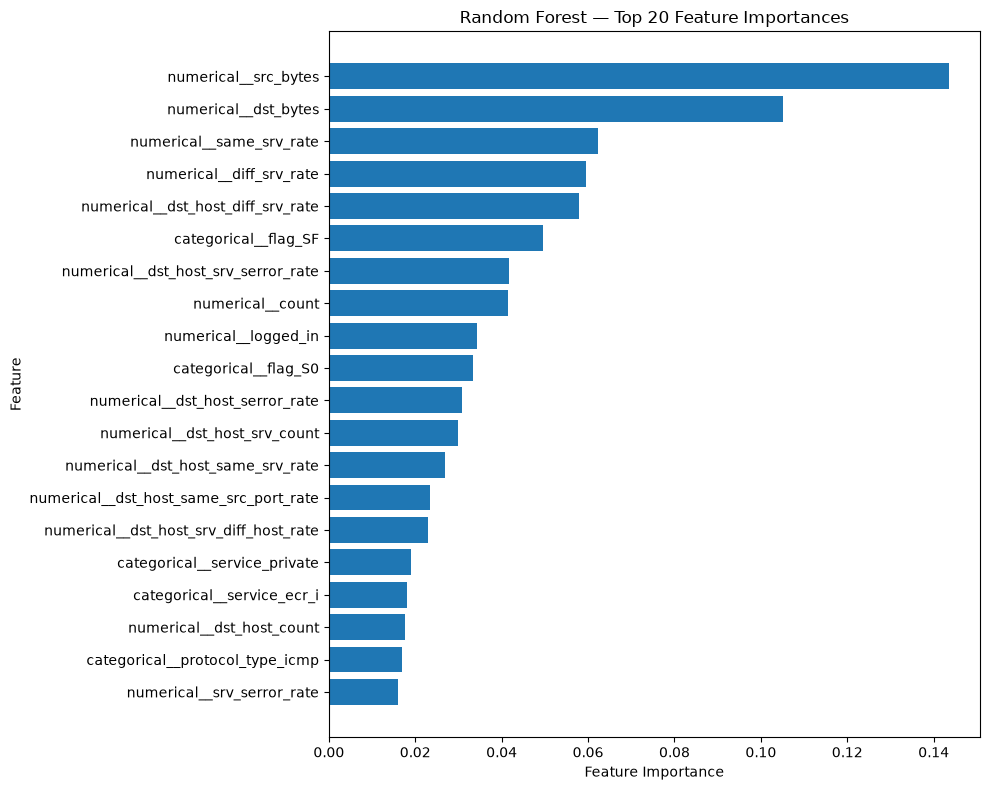

In [83]:
top20 = feature_importance_df.head(20).sort_values(
    by="importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest — Top 20 Feature Importances")

plt.tight_layout()
plt.show()

In [84]:
from sklearn.inspection import permutation_importance

sample_size = min(10000, X_test_processed.shape[0])

X_perm = X_test_processed[:sample_size]
y_perm = y_test.iloc[:sample_size] if hasattr(y_test, "iloc") else y_test[:sample_size]

perm_result = permutation_importance(
    rf_model,
    X_perm,
    y_perm,
    n_repeats=5,
    random_state=42,
    scoring="f1",
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values(
    by="importance_mean",
    ascending=False
)

display(permutation_df.head(20))

,feature,importance_mean,importance_std
84,numerical__src_bytes,0.012276,0.000710
114,numerical__dst_host_same_src_port_rate,0.003671,0.000417
85,numerical__dst_bytes,0.002589,0.000438
51,categorical__service_private,0.001789,0.000252
89,numerical__hot,0.001595,0.000043
91,numerical__logged_in,0.001551,0.000211
113,numerical__dst_host_diff_srv_rate,0.000904,0.000110
23,categorical__service_ftp_data,0.000732,0.000043
118,numerical__dst_host_rerror_rate,0.000646,0.000096
101,numerical__count,0.000602,0.000286


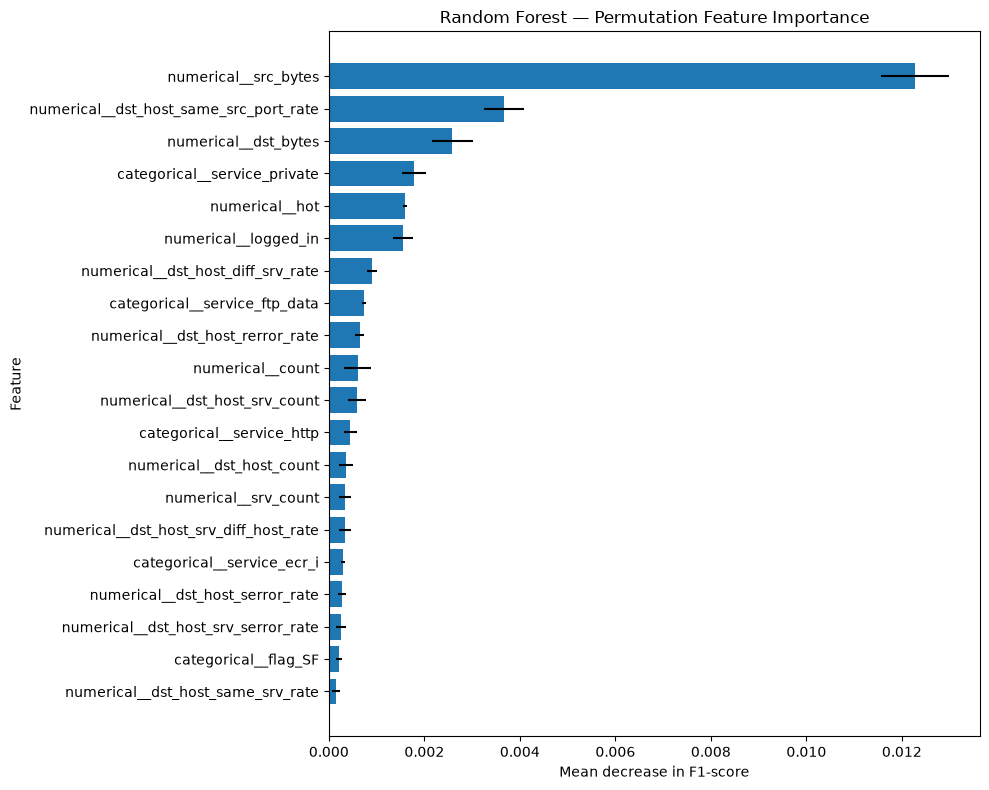

In [85]:
top20_perm = permutation_df.head(20).sort_values(
    by="importance_mean"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top20_perm["feature"],
    top20_perm["importance_mean"],
    xerr=top20_perm["importance_std"]
)

plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature")
plt.title("Random Forest — Permutation Feature Importance")

plt.tight_layout()
plt.show()

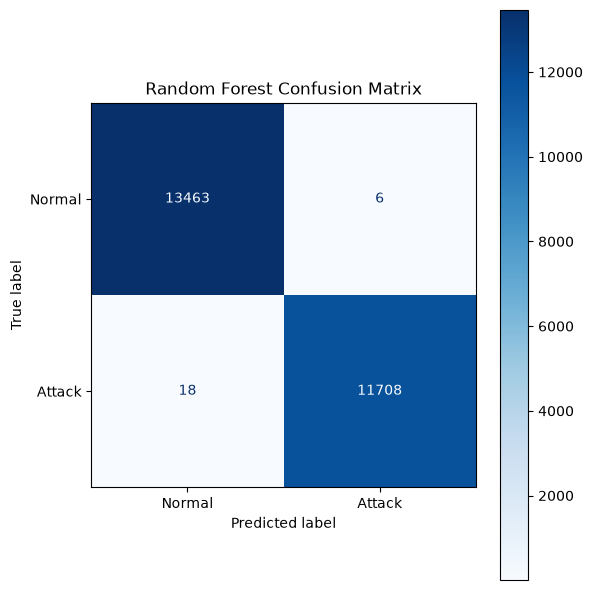

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Normal", "Attack"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

In [88]:
print("rf_model:", type(rf_model))

print("X_train shape:", X_train.shape)
print("X_train type:", type(X_train))

print("\nFirst few columns:")
print(X_train.columns[:10].tolist() if hasattr(X_train, "columns") else "No columns")

print("\nPipeline objects in notebook:")
for name in ["preprocessor", "preprocessor_rf", "rf_pipeline", "rf_model"]:
    if name in globals():
        print(name, "→", type(globals()[name]))

rf_model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
X_train shape: (100778, 40)
X_train type: <class 'pandas.DataFrame'>

First few columns:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot']

Pipeline objects in notebook:
preprocessor → <class 'sklearn.compose._column_transformer.ColumnTransformer'>
rf_model → <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [89]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf_model)
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_df = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Recall": cv_results["test_recall"],
    "F1": cv_results["test_f1"],
    "ROC-AUC": cv_results["test_roc_auc"]
})

print("=" * 70)
print("RANDOM FOREST - 5-FOLD CROSS-VALIDATION")
print("=" * 70)

display(cv_df)

print("\nMean ± Standard Deviation:")
print("-" * 40)

for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(
        f"{metric.upper():<10}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

RANDOM FOREST - 5-FOLD CROSS-VALIDATION


,Fold,Accuracy,Precision,Recall,F1,ROC-AUC
0,1,0.998809,0.999253,0.998188,0.998720,0.999993
1,2,0.998611,0.999573,0.997442,0.998506,0.999988
2,3,0.998462,0.999359,0.997335,0.998346,0.999994
3,4,0.998561,0.999466,0.997441,0.998453,0.999988
4,5,0.998809,0.999680,0.997761,0.998720,0.999994



Mean ± Standard Deviation:
----------------------------------------
ACCURACY  : 0.9987 ± 0.0001
PRECISION : 0.9995 ± 0.0002
RECALL    : 0.9976 ± 0.0003
F1        : 0.9985 ± 0.0001
ROC_AUC   : 1.0000 ± 0.0000


In [90]:

print("Target column:", y_train.name)

print("\nPotentially suspicious columns:")
for col in X_train.columns:
    if any(word in col.lower() for word in ["attack", "label", "target", "class", "family"]):
        print(col)

Target column: stage1_target

Potentially suspicious columns:


In [91]:
train_hash = pd.util.hash_pandas_object(X_train, index=False)
test_hash = pd.util.hash_pandas_object(X_test, index=False)

overlap = len(set(train_hash) & set(test_hash))

print("Duplicate rows shared between train and test:", overlap)

Duplicate rows shared between train and test: 5


In [93]:
# Transform the raw test data using the SAME preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Raw X_test shape:       ", X_test.shape)
print("Processed X_test shape: ", X_test_processed.shape)

# Predict using the trained Random Forest
y_pred = rf_model.predict(X_test_processed)
y_prob = rf_model.predict_proba(X_test_processed)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("\n" + "=" * 60)
print("RANDOM FOREST — FINAL TEST SET")
print("=" * 60)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Raw X_test shape:        (25195, 40)
Processed X_test shape:  (25195, 120)

RANDOM FOREST — FINAL TEST SET
Accuracy : 0.9990
Precision: 0.9995
Recall   : 0.9985
F1-Score: 0.9990
ROC-AUC  : 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13469
           1       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix:
[[13463     6]
 [   18 11708]]


In [94]:
print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

print("\nTraining:")
print(y_train.value_counts())
print("\nTraining percentages:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts())
print("\nTest percentages:")
print(y_test.value_counts(normalize=True) * 100)

TARGET DISTRIBUTION

Training:
stage1_target
0    53874
1    46904
Name: count, dtype: int64

Training percentages:
stage1_target
0    53.458096
1    46.541904
Name: proportion, dtype: float64

Test:
stage1_target
0    13469
1    11726
Name: count, dtype: int64

Test percentages:
stage1_target
0    53.45902
1    46.54098
Name: proportion, dtype: float64


In [95]:
print("\nPotential target-related columns:")

for col in X_train.columns:
    if any(
        word in col.lower()
        for word in ["attack", "label", "target", "class", "family"]
    ):
        print(col)
        


Potential target-related columns:


In [97]:
# Show variables that might contain attack-family information
print("Variables containing 'attack' or 'family':")

for name in globals():
    if "attack" in name.lower() or "family" in name.lower():
        print(name, "→", type(globals()[name]))
        

Variables containing 'attack' or 'family':
attack_categories → <class 'dict'>
label_to_family → <class 'dict'>
family → <class 'str'>
missed_attacks → <class 'pandas.DataFrame'>
test_attack_families → <class 'pandas.Series'>
family_accuracy → <class 'pandas.Series'>


In [98]:
print("\nColumns in X_test:")
print(X_test.columns.tolist())

print("\nColumns in your original test dataframe, if available:")

for name in ["test_df", "df_test", "test_data", "df", "data"]:
    if name in globals():
        obj = globals()[name]
        if hasattr(obj, "columns"):
            print(name, "→", obj.columns.tolist())


Columns in X_test:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

Columns in your original test dataframe, if available:
test_df → ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_

In [99]:
attack_family_test = test_attack_families.reset_index(drop=True)

print(attack_family_test.value_counts())
print("Length:", len(attack_family_test))
print("X_test:", len(X_test))

attack_family
Normal    13469
DoS        9105
Probe      2389
R2L         226
U2R           6
Name: count, dtype: int64
Length: 25195
X_test: 25195


In [100]:
results_df = pd.DataFrame({
    "actual": y_test.reset_index(drop=True),
    "predicted": pd.Series(y_pred).reset_index(drop=True),
    "attack_family": attack_family_test
})

print(results_df.head())
print(results_df.shape)

   actual  predicted attack_family
0       1          1           DoS
1       0          0        Normal
2       1          1           DoS
3       1          1           DoS
4       0          0        Normal
(25195, 3)


In [101]:
family_results = []

for family in results_df["attack_family"].unique():

    subset = results_df[
        results_df["attack_family"] == family
    ]

    correct = (
        subset["actual"] == subset["predicted"]
    ).sum()

    accuracy = correct / len(subset)

    family_results.append({
        "attack_family": family,
        "samples": len(subset),
        "correct": correct,
        "incorrect": len(subset) - correct,
        "accuracy": accuracy
    })

family_results_df = pd.DataFrame(family_results)

family_results_df = family_results_df.sort_values(
    "accuracy"
)

display(family_results_df)

,attack_family,samples,correct,incorrect,accuracy
3,R2L,226,216,10,0.955752
2,Probe,2389,2382,7,0.997070
1,Normal,13469,13463,6,0.999555
0,DoS,9105,9104,1,0.999890
4,U2R,6,6,0,1.000000


In [102]:
r2l_results = results_df[
    results_df["attack_family"] == "R2L"
].copy()

print("=" * 60)
print("R2L ERROR ANALYSIS")
print("=" * 60)

print("Total R2L samples:", len(r2l_results))

print("\nCorrect:", 
      (r2l_results["actual"] == r2l_results["predicted"]).sum())

print("Incorrect:",
      (r2l_results["actual"] != r2l_results["predicted"]).sum())

print("\nConfusion Matrix:")
print(
    pd.crosstab(
        r2l_results["actual"],
        r2l_results["predicted"],
        rownames=["Actual"],
        colnames=["Predicted"]
    )
)

R2L ERROR ANALYSIS
Total R2L samples: 226

Correct: 216
Incorrect: 10

Confusion Matrix:
Predicted   0    1
Actual            
1          10  216


In [103]:
print("\nMisclassified R2L samples:")

r2l_missed = r2l_results[
    r2l_results["actual"] != r2l_results["predicted"]
]

display(r2l_missed)


Misclassified R2L samples:


,actual,predicted,attack_family
7070,1,0,R2L
10683,1,0,R2L
14745,1,0,R2L
16075,1,0,R2L
18444,1,0,R2L
19788,1,0,R2L
21888,1,0,R2L
23289,1,0,R2L
24605,1,0,R2L
24932,1,0,R2L


In [104]:
r2l_missed_positions = results_df.index[
    (results_df["attack_family"] == "R2L") &
    (results_df["actual"] == 1) &
    (results_df["predicted"] == 0)
]

r2l_missed_features = X_test.iloc[r2l_missed_positions].copy()

display(r2l_missed_features)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
26872,179,tcp,ftp,SF,87,319,0,0,0,1,...,255,2,0.01,0.01,0.00,0.00,0.00,0.00,0.04,0.00
56279,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,2,2,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
52037,5063,tcp,other,S3,5133877,0,0,0,0,5,...,7,1,0.14,0.29,1.00,0.00,0.29,1.00,0.00,0.00
59000,0,tcp,ftp_data,SF,613,0,0,0,0,0,...,1,84,1.00,0.00,1.00,0.02,0.00,0.00,0.00,0.00
101346,23,tcp,telnet,SF,104,276,0,0,0,0,...,1,2,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
75944,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,221,82,0.35,0.02,0.35,0.02,0.00,0.00,0.00,0.00
50266,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,4,38,0.50,0.50,0.50,0.16,0.00,0.00,0.00,0.00
36827,12546,tcp,ftp,RSTO,358,1184,0,0,0,6,...,255,144,0.56,0.02,0.00,0.00,0.00,0.00,0.00,0.01
21445,299,tcp,telnet,SF,112,847,0,0,0,0,...,255,48,0.19,0.02,0.00,0.00,0.22,0.31,0.00,0.00
46547,192,tcp,ftp,SF,119,426,0,0,0,2,...,255,1,0.00,0.01,0.00,0.00,0.00,0.00,0.04,0.00


In [105]:
r2l_probabilities = rf_model.predict_proba(
    preprocessor.transform(r2l_missed_features)
)[:, 1]

r2l_probability_df = pd.DataFrame({
    "probability_attack": r2l_probabilities
})

display(r2l_probability_df)

,probability_attack
0,0.45
1,0.29
2,0.43
3,0.05
4,0.13
5,0.34
6,0.44
7,0.38
8,0.03
9,0.49


In [106]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Probability of class 1 for the ENTIRE test set
y_prob = rf_model.predict_proba(X_test_processed)[:, 1]

threshold_results = []

thresholds = [
    0.50,
    0.45,
    0.40,
    0.35,
    0.30,
    0.25,
    0.20,
    0.15,
    0.10
]

for threshold in thresholds:

    y_threshold = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_threshold
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_threshold),
        "precision": precision_score(y_test, y_threshold),
        "recall": recall_score(y_test, y_threshold),
        "f1": f1_score(y_test, y_threshold),
        "false_positives": fp,
        "false_negatives": fn
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,threshold,accuracy,precision,recall,f1,false_positives,false_negatives
0,0.50,0.999127,0.999488,0.998636,0.999062,6,16
1,0.45,0.999167,0.999317,0.998891,0.999104,8,13
2,0.40,0.999167,0.998977,0.999232,0.999105,12,9
3,0.35,0.999127,0.998807,0.999318,0.999062,14,8
4,0.30,0.998968,0.998381,0.999403,0.998892,19,7
5,0.25,0.998730,0.997617,0.999659,0.998637,28,4
6,0.20,0.998214,0.996514,0.999659,0.998084,41,4
7,0.15,0.997658,0.995330,0.999659,0.997490,55,4
8,0.10,0.996031,0.991794,0.999744,0.995753,97,3


In [107]:
r2l_all = X_test.loc[
    test_attack_families == "R2L"
]

print("Total R2L samples:", len(r2l_all))

display(r2l_all.describe(include="all").T)

Total R2L samples: 226


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
duration,226.0,NaN,NaN,NaN,697.862832,2336.966327,0.0,0.0,0.0,3.75,15157.0
protocol_type,226,1,tcp,226,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,226,6,ftp_data,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flag,226,5,SF,209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_bytes,226.0,NaN,NaN,NaN,375362.39823,1326924.48298,0.0,334.0,334.0,1230.0,5135678.0
dst_bytes,226.0,NaN,NaN,NaN,119143.292035,761455.655102,0.0,0.0,0.0,2449.0,5153460.0
land,226.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
wrong_fragment,226.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
urgent,226.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
hot,226.0,NaN,NaN,NaN,8.061947,12.267959,0.0,0.0,0.0,28.0,28.0


In [108]:
normal_samples = X_test.loc[
    test_attack_families == "Normal"
]

comparison = pd.DataFrame({
    "R2L_mean": r2l_all.select_dtypes(include="number").mean(),
    "Normal_mean": normal_samples.select_dtypes(include="number").mean()
})

comparison["difference"] = (
    comparison["R2L_mean"] - comparison["Normal_mean"]
)

display(
    comparison.sort_values(
        "difference",
        key=abs,
        ascending=False
    ).head(20)
)

,R2L_mean,Normal_mean,difference
src_bytes,375362.398230,16462.211226,358900.187004
dst_bytes,119143.292035,5141.227411,114002.064624
duration,697.862832,168.532334,529.330498
dst_host_srv_count,44.747788,190.434702,-145.686914
dst_host_count,87.553097,148.013364,-60.460267
srv_count,2.539823,27.703022,-25.163199
count,1.278761,22.566041,-21.287279
hot,8.061947,0.281016,7.780931
dst_host_same_src_port_rate,0.607301,0.118227,0.489074
num_compromised,0.097345,0.475388,-0.378043


In [109]:

train_duplicates = X_train.duplicated().sum()
test_duplicates = X_test.duplicated().sum()

print("Duplicate rows in training:", train_duplicates)
print("Duplicate rows in test:", test_duplicates)

Duplicate rows in training: 11
Duplicate rows in test: 0


In [110]:
train_hashes = pd.util.hash_pandas_object(
    X_train,
    index=False
)

test_hashes = pd.util.hash_pandas_object(
    X_test,
    index=False
)

overlap = len(
    set(train_hashes) & set(test_hashes)
)

print("Exact feature-row overlap:", overlap)

Exact feature-row overlap: 5


In [111]:
r2l_errors = results_df[
    (results_df["attack_family"] == "R2L") &
    (results_df["actual"] == 1) &
    (results_df["predicted"] == 0)
]

print("Missed R2L attacks:", len(r2l_errors))

Missed R2L attacks: 10


In [112]:
train_hashes = pd.util.hash_pandas_object(X_train, index=False)
test_hashes = pd.util.hash_pandas_object(X_test, index=False)

overlap = len(set(train_hashes) & set(test_hashes))

print("Exact train-test feature overlap:", overlap)

Exact train-test feature overlap: 5


In [ ]:

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
test_attack_families_reset = test_attack_families.reset_index(drop=True)

results_fixed = pd.DataFrame({
    "actual": y_test_reset,
    "predicted": y_pred,
    "attack_family": test_attack_families_reset
})


r2l_errors_fixed = results_fixed[
    (results_fixed["attack_family"] == "R2L") &
    (results_fixed["actual"] == 1) &
    (results_fixed["predicted"] == 0)
]

print("Total missed R2L attacks:", len(r2l_errors_fixed))

print("\nPositions of missed R2L attacks:")
print(r2l_errors_fixed.index.tolist())

print("\nMissed R2L samples:")
display(
    X_test_reset.loc[r2l_errors_fixed.index])

Total missed R2L attacks: 10

Positions of missed R2L attacks:
[7070, 10683, 14745, 16075, 18444, 19788, 21888, 23289, 24605, 24932]

Missed R2L samples:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
7070,179,tcp,ftp,SF,87,319,0,0,0,1,...,255,2,0.01,0.01,0.00,0.00,0.00,0.00,0.04,0.00
10683,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,2,2,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
14745,5063,tcp,other,S3,5133877,0,0,0,0,5,...,7,1,0.14,0.29,1.00,0.00,0.29,1.00,0.00,0.00
16075,0,tcp,ftp_data,SF,613,0,0,0,0,0,...,1,84,1.00,0.00,1.00,0.02,0.00,0.00,0.00,0.00
18444,23,tcp,telnet,SF,104,276,0,0,0,0,...,1,2,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
19788,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,221,82,0.35,0.02,0.35,0.02,0.00,0.00,0.00,0.00
21888,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,4,38,0.50,0.50,0.50,0.16,0.00,0.00,0.00,0.00
23289,12546,tcp,ftp,RSTO,358,1184,0,0,0,6,...,255,144,0.56,0.02,0.00,0.00,0.00,0.00,0.00,0.01
24605,299,tcp,telnet,SF,112,847,0,0,0,0,...,255,48,0.19,0.02,0.00,0.00,0.22,0.31,0.00,0.00
24932,192,tcp,ftp,SF,119,426,0,0,0,2,...,255,1,0.00,0.01,0.00,0.00,0.00,0.00,0.04,0.00


In [118]:
# Find variables that might contain prediction probabilities

for name, value in globals().items():
    try:
        if hasattr(value, "shape"):
            shape = value.shape
            
            # Look for something shaped like the test set
            if len(shape) >= 1 and shape[0] == len(X_test):
                print(name, "→", type(value), shape)
    except:
        pass

X_test → <class 'pandas.DataFrame'> (25195, 40)
y_test → <class 'pandas.Series'> (25195,)
X_test_processed → <class 'numpy.ndarray'> (25195, 120)
X_test_scaled → <class 'numpy.ndarray'> (25195, 120)
y_pred → <class 'numpy.ndarray'> (25195,)
results → <class 'pandas.DataFrame'> (25195, 3)
balanced_pred → <class 'numpy.ndarray'> (25195,)
balanced_results → <class 'pandas.DataFrame'> (25195, 44)
X_test_unscaled → <class 'numpy.ndarray'> (25195, 120)
rf_pred → <class 'numpy.ndarray'> (25195,)
test_hashes → <class 'pandas.Series'> (25195,)
test_df → <class 'pandas.DataFrame'> (25195, 41)
misclassified → <class 'numpy.ndarray'> (25195,)
test_families → <class 'pandas.Series'> (25195,)
test_features → <class 'numpy.ndarray'> (25195, 120)
lr_pred → <class 'numpy.ndarray'> (25195,)
rf_prob → <class 'numpy.ndarray'> (25195,)
lr_prob → <class 'numpy.ndarray'> (25195,)
test_attack_families → <class 'pandas.Series'> (25195,)
test_hash → <class 'pandas.Series'> (25195,)
y_prob → <class 'numpy.ndarra

In [119]:
print("Random Forest classes:")
print(rf_model.classes_)

Random Forest classes:
[0 1]


In [120]:

y_proba_all = rf_model.predict_proba(X_test_processed)[:, 1]

print("Probability array shape:", y_proba_all.shape)
print("First 10 probabilities:")
print(y_proba_all[:10])

Probability array shape: (25195,)
First 10 probabilities:
[1. 0. 1. 1. 0. 0. 0. 0. 1. 1.]


In [121]:


r2l_positions = r2l_errors_fixed.index

r2l_probability_analysis = pd.DataFrame({
    "position": r2l_positions,
    "probability_attack": y_proba_all[r2l_positions]
})

display(
    r2l_probability_analysis.sort_values(
        "probability_attack"
    )
)

,position,probability_attack
8,24605,0.03
3,16075,0.05
4,18444,0.13
1,10683,0.29
5,19788,0.34
7,23289,0.38
2,14745,0.43
6,21888,0.44
0,7070,0.45
9,24932,0.49


In [122]:
threshold = 0.40

y_pred_040 = (
    y_proba_all >= threshold
).astype(int)

In [123]:

r2l_positions = r2l_errors_fixed.index

r2l_probability_analysis = pd.DataFrame({
    "position": r2l_positions,
    "probability_attack": rf_prob[r2l_positions]
})

display(
    r2l_probability_analysis.sort_values(
        "probability_attack"
    )
)

,position,probability_attack
8,24605,0.03
3,16075,0.05
4,18444,0.13
1,10683,0.29
5,19788,0.34
7,23289,0.38
2,14745,0.43
6,21888,0.44
0,7070,0.45
9,24932,0.49


In [124]:
r2l_missed_features = X_test_reset.loc[r2l_positions].copy()

display(r2l_missed_features)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
7070,179,tcp,ftp,SF,87,319,0,0,0,1,...,255,2,0.01,0.01,0.00,0.00,0.00,0.00,0.04,0.00
10683,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,2,2,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
14745,5063,tcp,other,S3,5133877,0,0,0,0,5,...,7,1,0.14,0.29,1.00,0.00,0.29,1.00,0.00,0.00
16075,0,tcp,ftp_data,SF,613,0,0,0,0,0,...,1,84,1.00,0.00,1.00,0.02,0.00,0.00,0.00,0.00
18444,23,tcp,telnet,SF,104,276,0,0,0,0,...,1,2,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
19788,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,221,82,0.35,0.02,0.35,0.02,0.00,0.00,0.00,0.00
21888,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,4,38,0.50,0.50,0.50,0.16,0.00,0.00,0.00,0.00
23289,12546,tcp,ftp,RSTO,358,1184,0,0,0,6,...,255,144,0.56,0.02,0.00,0.00,0.00,0.00,0.00,0.01
24605,299,tcp,telnet,SF,112,847,0,0,0,0,...,255,48,0.19,0.02,0.00,0.00,0.22,0.31,0.00,0.00
24932,192,tcp,ftp,SF,119,426,0,0,0,2,...,255,1,0.00,0.01,0.00,0.00,0.00,0.00,0.04,0.00


In [125]:
r2l_analysis = X_test_reset.loc[r2l_positions].copy()

r2l_analysis["attack_probability"] = rf_prob[r2l_positions]
r2l_analysis["actual"] = y_test_reset.loc[r2l_positions].values
r2l_analysis["predicted"] = y_pred[r2l_positions]

display(r2l_analysis)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_probability,actual,predicted
7070,179,tcp,ftp,SF,87,319,0,0,0,1,...,0.01,0.00,0.00,0.00,0.00,0.04,0.00,0.45,1,0
10683,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.29,1,0
14745,5063,tcp,other,S3,5133877,0,0,0,0,5,...,0.29,1.00,0.00,0.29,1.00,0.00,0.00,0.43,1,0
16075,0,tcp,ftp_data,SF,613,0,0,0,0,0,...,0.00,1.00,0.02,0.00,0.00,0.00,0.00,0.05,1,0
18444,23,tcp,telnet,SF,104,276,0,0,0,0,...,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.13,1,0
19788,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,0.02,0.35,0.02,0.00,0.00,0.00,0.00,0.34,1,0
21888,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,0.50,0.50,0.16,0.00,0.00,0.00,0.00,0.44,1,0
23289,12546,tcp,ftp,RSTO,358,1184,0,0,0,6,...,0.02,0.00,0.00,0.00,0.00,0.00,0.01,0.38,1,0
24605,299,tcp,telnet,SF,112,847,0,0,0,0,...,0.02,0.00,0.00,0.22,0.31,0.00,0.00,0.03,1,0
24932,192,tcp,ftp,SF,119,426,0,0,0,2,...,0.01,0.00,0.00,0.00,0.00,0.04,0.00,0.49,1,0


In [126]:
y_pred_040 = (rf_prob >= 0.40).astype(int)

r2l_040 = pd.DataFrame({
    "actual": y_test_reset,
    "predicted": y_pred_040,
    "attack_family": test_attack_families_reset
})

r2l_040_errors = r2l_040[
    (r2l_040["attack_family"] == "R2L") &
    (r2l_040["actual"] == 1) &
    (r2l_040["predicted"] == 0)
]

print("R2L attacks missed at threshold 0.40:",
      len(r2l_040_errors))

display(r2l_040_errors)

R2L attacks missed at threshold 0.40: 6


,actual,predicted,attack_family
10683,1,0,R2L
16075,1,0,R2L
18444,1,0,R2L
19788,1,0,R2L
23289,1,0,R2L
24605,1,0,R2L


In [127]:
r2l_missed_positions = r2l_040_errors.index

r2l_missed = X_test_reset.loc[r2l_missed_positions].copy()

r2l_missed["attack_probability"] = rf_prob[r2l_missed_positions]

display(r2l_missed)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_probability
10683,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,2,1.00,0.00,1.00,0.00,0.00,0.00,0.0,0.00,0.29
16075,0,tcp,ftp_data,SF,613,0,0,0,0,0,...,84,1.00,0.00,1.00,0.02,0.00,0.00,0.0,0.00,0.05
18444,23,tcp,telnet,SF,104,276,0,0,0,0,...,2,1.00,0.00,1.00,1.00,0.00,0.00,0.0,0.00,0.13
19788,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,82,0.35,0.02,0.35,0.02,0.00,0.00,0.0,0.00,0.34
23289,12546,tcp,ftp,RSTO,358,1184,0,0,0,6,...,144,0.56,0.02,0.00,0.00,0.00,0.00,0.0,0.01,0.38
24605,299,tcp,telnet,SF,112,847,0,0,0,0,...,48,0.19,0.02,0.00,0.00,0.22,0.31,0.0,0.00,0.03


In [128]:
print("Attack probabilities of the 6 missed R2L attacks:")

print(
    pd.DataFrame({
        "position": r2l_missed_positions,
        "attack_probability": rf_prob[r2l_missed_positions]
    }).sort_values("attack_probability")
)

Attack probabilities of the 6 missed R2L attacks:
   position  attack_probability
5     24605                0.03
1     16075                0.05
2     18444                0.13
0     10683                0.29
3     19788                0.34
4     23289                0.38


In [129]:

r2l_correct = results_fixed[
    (results_fixed["attack_family"] == "R2L") &
    (results_fixed["actual"] == 1) &
    (results_fixed["predicted"] == 1)
]

print("Correctly detected R2L attacks:", len(r2l_correct))

display(
    X_test_reset.loc[r2l_correct.index].head(10)
)

Correctly detected R2L attacks: 216


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
52,1,tcp,ftp,SF,1251,2451,0,0,0,28,...,255,36,0.14,0.02,0.00,0.00,0.08,0.0,0.00,0.0
364,2,tcp,ftp,SF,1231,2451,0,0,0,28,...,225,53,0.24,0.02,0.00,0.00,0.00,0.0,0.01,0.0
397,2,tcp,ftp,SF,1227,2449,0,0,0,28,...,255,60,0.24,0.02,0.00,0.00,0.00,0.0,0.00,0.0
687,1,tcp,ftp,SF,1151,2445,0,0,0,28,...,112,10,0.09,0.05,0.01,0.00,0.02,0.0,0.07,0.0
720,1,tcp,ftp,SF,1253,2453,0,0,0,28,...,255,87,0.34,0.02,0.01,0.00,0.00,0.0,0.00,0.0
980,1,tcp,ftp,SF,1223,2451,0,0,0,28,...,219,47,0.21,0.02,0.00,0.00,0.00,0.0,0.01,0.0
1023,5063,tcp,ftp_data,SF,5133876,0,0,0,0,1,...,4,36,1.00,0.00,1.00,0.14,0.00,0.0,0.00,0.0
1099,0,tcp,ftp,SF,1205,2447,0,0,0,28,...,255,94,0.37,0.02,0.00,0.00,0.00,0.0,0.01,0.0
1324,4,tcp,ftp_data,SF,832,0,0,0,0,0,...,3,33,1.00,0.00,1.00,0.15,0.00,0.0,0.00,0.0
1387,4,tcp,ftp_data,SF,832,0,0,0,0,0,...,10,42,0.90,0.20,1.00,0.12,0.00,0.0,0.00,0.0


In [130]:

import pandas as pd
import numpy as np

# Reset everything so positions line up safely
X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
test_attack_families_reset = test_attack_families.reset_index(drop=True)

# Use the probability variable that actually exists
y_prob = rf_prob[:, 1] if rf_prob.ndim == 2 else rf_prob

# Predictions at our selected threshold
threshold = 0.40
y_threshold = (y_prob >= threshold).astype(int)

# Build complete analysis dataframe
r2l_analysis = X_test_reset.copy()

r2l_analysis["actual"] = y_test_reset
r2l_analysis["predicted"] = y_threshold
r2l_analysis["probability_attack"] = y_prob
r2l_analysis["attack_family"] = test_attack_families_reset

# Only R2L attacks
r2l_only = r2l_analysis[
    r2l_analysis["attack_family"] == "R2L"
].copy()

# Split into detected and missed
r2l_detected = r2l_only[
    r2l_only["actual"].eq(1) &
    r2l_only["predicted"].eq(1)
]

r2l_missed = r2l_only[
    r2l_only["actual"].eq(1) &
    r2l_only["predicted"].eq(0)
]

print("R2L correctly detected:", len(r2l_detected))
print("R2L missed:", len(r2l_missed))

print("\nMissed R2L attacks:")
display(
    r2l_missed[
        ["probability_attack", "duration", "protocol_type",
         "service", "flag", "src_bytes", "dst_bytes",
         "hot", "logged_in", "count", "srv_count",
         "same_srv_rate", "diff_srv_rate"]
    ]
)

print("\nProbability statistics:")
print("Detected R2L:")
print(r2l_detected["probability_attack"].describe())

print("\nMissed R2L:")
print(r2l_missed["probability_attack"].describe())

R2L correctly detected: 220
R2L missed: 6

Missed R2L attacks:


,probability_attack,duration,protocol_type,service,flag,src_bytes,dst_bytes,hot,logged_in,count,srv_count,same_srv_rate,diff_srv_rate
10683,0.29,0,tcp,ftp_data,SF,334,0,0,1,2,2,1.0,0.0
16075,0.05,0,tcp,ftp_data,SF,613,0,0,1,1,2,1.0,0.0
18444,0.13,23,tcp,telnet,SF,104,276,0,0,1,1,1.0,0.0
19788,0.34,0,tcp,ftp_data,SF,334,0,0,1,1,1,1.0,0.0
23289,0.38,12546,tcp,ftp,RSTO,358,1184,6,1,1,1,1.0,0.0
24605,0.03,299,tcp,telnet,SF,112,847,0,0,1,1,1.0,0.0



Probability statistics:
Detected R2L:
count    220.000000
mean       0.942735
std        0.116102
min        0.430000
25%        0.957500
50%        1.000000
75%        1.000000
max        1.000000
Name: probability_attack, dtype: float64

Missed R2L:
count    6.000000
mean     0.203333
std      0.152534
min      0.030000
25%      0.070000
50%      0.210000
75%      0.327500
max      0.380000
Name: probability_attack, dtype: float64


In [131]:
numeric_features = X_test_reset.select_dtypes(
    include=np.number
).columns.tolist()

comparison = pd.DataFrame({
    "detected_mean": r2l_detected[numeric_features].mean(),
    "missed_mean": r2l_missed[numeric_features].mean()
})

comparison["absolute_difference"] = (
    comparison["missed_mean"] -
    comparison["detected_mean"]
).abs()
    
comparison = comparison.sort_values(
    "absolute_difference",
    ascending=False
)

display(comparison.head(20))

,detected_mean,missed_mean,absolute_difference
src_bytes,385591.122727,309.166667,385281.956061
dst_bytes,122382.168182,384.500000,121997.668182
duration,658.404545,2144.666667,1486.262121
dst_host_count,86.600000,122.500000,35.900000
dst_host_srv_count,44.322727,60.333333,16.010606
hot,8.254545,1.000000,7.254545
srv_count,2.572727,1.333333,1.239394
num_failed_logins,0.054545,0.833333,0.778788
logged_in,0.909091,0.666667,0.242424
srv_diff_host_rate,0.020000,0.166667,0.146667


In [132]:

categorical_features = [
    "protocol_type",
    "service",
    "flag"
]

for feature in categorical_features:
    print("\n" + "=" * 60)
    print(feature.upper())
    print("=" * 60)

    print("\nDetected R2L:")
    print(
        r2l_detected[feature]
        .value_counts(normalize=True)
        .head(15)
    )

    print("\nMissed R2L:")
    print(
        r2l_missed[feature]
        .value_counts(normalize=True)
        .head(15)
    )


PROTOCOL_TYPE

Detected R2L:
protocol_type
tcp    1.0
Name: proportion, dtype: float64

Missed R2L:
protocol_type
tcp    1.0
Name: proportion, dtype: float64

SERVICE

Detected R2L:
service
ftp_data    0.609091
ftp         0.309091
telnet      0.059091
other       0.009091
imap4       0.009091
http        0.004545
Name: proportion, dtype: float64

Missed R2L:
service
ftp_data    0.500000
telnet      0.333333
ftp         0.166667
Name: proportion, dtype: float64

FLAG

Detected R2L:
flag
SF      0.927273
RSTO    0.045455
RSTR    0.009091
S3      0.009091
SH      0.009091
Name: proportion, dtype: float64

Missed R2L:
flag
SF      0.833333
RSTO    0.166667
Name: proportion, dtype: float64


In [133]:

print("Missed R2L probability:")
display(
    r2l_missed[
        [
            "probability_attack",
            "service",
            "flag",
            "duration",
            "src_bytes",
            "dst_bytes",
            "hot",
            "logged_in",
            "count",
            "srv_count",
            "same_srv_rate",
            "diff_srv_rate"
        ]
    ].sort_values("probability_attack", ascending=False)
)

print("\nProbability range:")
print(
    r2l_missed["probability_attack"]
    .describe()
)

Missed R2L probability:


,probability_attack,service,flag,duration,src_bytes,dst_bytes,hot,logged_in,count,srv_count,same_srv_rate,diff_srv_rate
23289,0.38,ftp,RSTO,12546,358,1184,6,1,1,1,1.0,0.0
19788,0.34,ftp_data,SF,0,334,0,0,1,1,1,1.0,0.0
10683,0.29,ftp_data,SF,0,334,0,0,1,2,2,1.0,0.0
18444,0.13,telnet,SF,23,104,276,0,0,1,1,1.0,0.0
16075,0.05,ftp_data,SF,0,613,0,0,1,1,2,1.0,0.0
24605,0.03,telnet,SF,299,112,847,0,0,1,1,1.0,0.0



Probability range:
count    6.000000
mean     0.203333
std      0.152534
min      0.030000
25%      0.070000
50%      0.210000
75%      0.327500
max      0.380000
Name: probability_attack, dtype: float64


In [134]:

print("Detected R2L probability:")
print(r2l_detected["probability_attack"].describe())

print("\nMissed R2L probability:")
print(r2l_missed["probability_attack"].describe())

print("\nHighest probability among missed:")
print(r2l_missed["probability_attack"].max())

print("\nLowest probability among detected:")
print(r2l_detected["probability_attack"].min())

Detected R2L probability:
count    220.000000
mean       0.942735
std        0.116102
min        0.430000
25%        0.957500
50%        1.000000
75%        1.000000
max        1.000000
Name: probability_attack, dtype: float64

Missed R2L probability:
count    6.000000
mean     0.203333
std      0.152534
min      0.030000
25%      0.070000
50%      0.210000
75%      0.327500
max      0.380000
Name: probability_attack, dtype: float64

Highest probability among missed:
0.38

Lowest probability among detected:
0.43


In [135]:

key_features = [
    "src_bytes",
    "dst_bytes",
    "duration",
    "hot",
    "logged_in",
    "count",
    "srv_count",
    "same_srv_rate",
    "diff_srv_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

summary = pd.DataFrame({
    "Detected_R2L_mean": r2l_detected[key_features].mean(),
    "Missed_R2L_mean": r2l_missed[key_features].mean(),
    "Detected_R2L_median": r2l_detected[key_features].median(),
    "Missed_R2L_median": r2l_missed[key_features].median()
})

summary["mean_difference"] = (
    summary["Missed_R2L_mean"] -
    summary["Detected_R2L_mean"]
).abs()

display(
    summary.sort_values(
        "mean_difference",
        ascending=False
    )
)

,Detected_R2L_mean,Missed_R2L_mean,Detected_R2L_median,Missed_R2L_median,mean_difference
src_bytes,385591.122727,309.166667,334.000,334.000,385281.956061
dst_bytes,122382.168182,384.500000,0.000,138.000,121997.668182
duration,658.404545,2144.666667,0.000,11.500,1486.262121
dst_host_count,86.600000,122.500000,9.000,111.500,35.900000
dst_host_srv_count,44.322727,60.333333,36.000,65.000,16.010606
hot,8.254545,1.000000,0.000,0.000,7.254545
srv_count,2.572727,1.333333,1.000,1.000,1.239394
logged_in,0.909091,0.666667,1.000,1.000,0.242424
count,1.281818,1.166667,1.000,1.000,0.115152
dst_host_srv_diff_host_rate,0.082045,0.173333,0.045,0.010,0.091288


In [136]:

print("Missed R2L attacks and their probabilities:\n")

display(
    r2l_missed[
        [
            "probability_attack",
            "service",
            "flag",
            "duration",
            "src_bytes",
            "dst_bytes",
            "hot",
            "logged_in",
            "count",
            "srv_count",
            "same_srv_rate",
            "dst_host_same_srv_rate"
        ]
    ].sort_values(
        "probability_attack",
        ascending=False
    )
)

Missed R2L attacks and their probabilities:



,probability_attack,service,flag,duration,src_bytes,dst_bytes,hot,logged_in,count,srv_count,same_srv_rate,dst_host_same_srv_rate
23289,0.38,ftp,RSTO,12546,358,1184,6,1,1,1,1.0,0.56
19788,0.34,ftp_data,SF,0,334,0,0,1,1,1,1.0,0.35
10683,0.29,ftp_data,SF,0,334,0,0,1,2,2,1.0,1.00
18444,0.13,telnet,SF,23,104,276,0,0,1,1,1.0,1.00
16075,0.05,ftp_data,SF,0,613,0,0,1,1,2,1.0,1.00
24605,0.03,telnet,SF,299,112,847,0,0,1,1,1.0,0.19


In [137]:
print("Detected R2L probability range:")
print(
    f"min = {r2l_detected['probability_attack'].min():.4f}"
)
print(
    f"median = {r2l_detected['probability_attack'].median():.4f}"
)
print(
    f"max = {r2l_detected['probability_attack'].max():.4f}"
)

print("\nMissed R2L probability range:")
print(
    f"min = {r2l_missed['probability_attack'].min():.4f}"
)
print(
    f"median = {r2l_missed['probability_attack'].median():.4f}"
)
print(
    f"max = {r2l_missed['probability_attack'].max():.4f}"
)


Detected R2L probability range:
min = 0.4300
median = 1.0000
max = 1.0000

Missed R2L probability range:
min = 0.0300
median = 0.2100
max = 0.3800


In [138]:
# Get the six missed R2L positions
r2l_missed_positions = results_fixed[
    (results_fixed["actual"] == 1) &
    (results_fixed["predicted"] == 0) &
    (results_fixed["attack_family"] == "R2L")
].index

print("Missed R2L positions:")
print(r2l_missed_positions.tolist())

print("\nMissed R2L samples:")
display(
    X_test_reset.loc[
        r2l_missed_positions
    ].copy()
)

Missed R2L positions:
[7070, 10683, 14745, 16075, 18444, 19788, 21888, 23289, 24605, 24932]

Missed R2L samples:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
7070,179,tcp,ftp,SF,87,319,0,0,0,1,...,255,2,0.01,0.01,0.00,0.00,0.00,0.00,0.04,0.00
10683,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,2,2,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
14745,5063,tcp,other,S3,5133877,0,0,0,0,5,...,7,1,0.14,0.29,1.00,0.00,0.29,1.00,0.00,0.00
16075,0,tcp,ftp_data,SF,613,0,0,0,0,0,...,1,84,1.00,0.00,1.00,0.02,0.00,0.00,0.00,0.00
18444,23,tcp,telnet,SF,104,276,0,0,0,0,...,1,2,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
19788,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,221,82,0.35,0.02,0.35,0.02,0.00,0.00,0.00,0.00
21888,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,4,38,0.50,0.50,0.50,0.16,0.00,0.00,0.00,0.00
23289,12546,tcp,ftp,RSTO,358,1184,0,0,0,6,...,255,144,0.56,0.02,0.00,0.00,0.00,0.00,0.00,0.01
24605,299,tcp,telnet,SF,112,847,0,0,0,0,...,255,48,0.19,0.02,0.00,0.00,0.22,0.31,0.00,0.00
24932,192,tcp,ftp,SF,119,426,0,0,0,2,...,255,1,0.00,0.01,0.00,0.00,0.00,0.00,0.04,0.00


In [140]:

r2l_probability = y_prob

# R2L missed positions at threshold 0.40
r2l_missed_positions = np.where(
    (test_attack_families_reset.values == "R2L") &
    (y_test_reset.values == 1) &
    (y_threshold == 0)
)[0]

print("Number of missed R2L attacks:", len(r2l_missed_positions))
print("Positions:", r2l_missed_positions.tolist())

# Build a clean dataframe using POSITIONAL indexing
r2l_missed_analysis = X_test_reset.iloc[r2l_missed_positions].copy()

r2l_missed_analysis["probability_attack"] = (
    r2l_probability[r2l_missed_positions]
)

r2l_missed_analysis["actual"] = (
    y_test_reset.iloc[r2l_missed_positions].values
)

r2l_missed_analysis["attack_family"] = (
    test_attack_families_reset.iloc[r2l_missed_positions].values
)

display(r2l_missed_analysis)

Number of missed R2L attacks: 6
Positions: [10683, 16075, 18444, 19788, 23289, 24605]


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,probability_attack,actual,attack_family
10683,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,0.00,1.00,0.00,0.00,0.00,0.0,0.00,0.29,1,R2L
16075,0,tcp,ftp_data,SF,613,0,0,0,0,0,...,0.00,1.00,0.02,0.00,0.00,0.0,0.00,0.05,1,R2L
18444,23,tcp,telnet,SF,104,276,0,0,0,0,...,0.00,1.00,1.00,0.00,0.00,0.0,0.00,0.13,1,R2L
19788,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,0.02,0.35,0.02,0.00,0.00,0.0,0.00,0.34,1,R2L
23289,12546,tcp,ftp,RSTO,358,1184,0,0,0,6,...,0.02,0.00,0.00,0.00,0.00,0.0,0.01,0.38,1,R2L
24605,299,tcp,telnet,SF,112,847,0,0,0,0,...,0.02,0.00,0.00,0.22,0.31,0.0,0.00,0.03,1,R2L


In [141]:

r2l_detected_positions = np.where(
    (test_attack_families_reset.values == "R2L") &
    (y_test_reset.values == 1) &
    (y_threshold == 1)
)[0]

r2l_detected = X_test_reset.iloc[r2l_detected_positions].copy()
r2l_missed = X_test_reset.iloc[r2l_missed_positions].copy()

print("Detected R2L:", len(r2l_detected))
print("Missed R2L:", len(r2l_missed))

comparison_features = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "hot",
    "logged_in",
    "count",
    "srv_count",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

comparison = pd.DataFrame({
    "detected_mean": r2l_detected[comparison_features].mean(),
    "missed_mean": r2l_missed[comparison_features].mean()
})

comparison["difference"] = (
    comparison["detected_mean"] -
    comparison["missed_mean"]
)

display(comparison.sort_values(
    "difference",
    key=lambda x: x.abs(),
    ascending=False
))

Detected R2L: 220
Missed R2L: 6


,detected_mean,missed_mean,difference
src_bytes,385591.122727,309.166667,385281.956061
dst_bytes,122382.168182,384.500000,121997.668182
duration,658.404545,2144.666667,-1486.262121
dst_host_count,86.600000,122.500000,-35.900000
dst_host_srv_count,44.322727,60.333333,-16.010606
hot,8.254545,1.000000,7.254545
srv_count,2.572727,1.333333,1.239394
logged_in,0.909091,0.666667,0.242424
count,1.281818,1.166667,0.115152
dst_host_srv_diff_host_rate,0.082045,0.173333,-0.091288


In [142]:

print("SERVICE")
display(
    r2l_missed_analysis["service"]
    .value_counts(normalize=True)
)

print("\nFLAG")
display(
    r2l_missed_analysis["flag"]
    .value_counts(normalize=True)
)

print("\nPROTOCOL")
display(
    r2l_missed_analysis["protocol_type"]
    .value_counts(normalize=True)
)

SERVICE


service
ftp_data    0.500000
telnet      0.333333
ftp         0.166667
Name: proportion, dtype: float64


FLAG


flag
SF      0.833333
RSTO    0.166667
Name: proportion, dtype: float64


PROTOCOL


protocol_type
tcp    1.0
Name: proportion, dtype: float64

In [143]:

display(
    r2l_missed_analysis[
        [
            "service",
            "flag",
            "src_bytes",
            "dst_bytes",
            "duration",
            "hot",
            "logged_in",
            "probability_attack"
        ]
    ].sort_values("probability_attack")
)

,service,flag,src_bytes,dst_bytes,duration,hot,logged_in,probability_attack
24605,telnet,SF,112,847,299,0,0,0.03
16075,ftp_data,SF,613,0,0,0,1,0.05
18444,telnet,SF,104,276,23,0,0,0.13
10683,ftp_data,SF,334,0,0,0,1,0.29
19788,ftp_data,SF,334,0,0,0,1,0.34
23289,ftp,RSTO,358,1184,12546,6,1,0.38


In [144]:

import numpy as np
import pandas as pd

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)
test_attack_families_reset = test_attack_families.reset_index(drop=True)

r2l_probability = y_prob

y_threshold = (r2l_probability >= 0.40).astype(int)

r2l_missed_positions = np.where(
    (test_attack_families_reset.values == "R2L") &
    (y_test_reset.values == 1) &
    (y_threshold == 0)
)[0]

print("Number of missed R2L attacks:", len(r2l_missed_positions))
print("Positions:", r2l_missed_positions.tolist())

r2l_missed_analysis = X_test_reset.iloc[r2l_missed_positions].copy()

r2l_missed_analysis["probability_attack"] = (
    r2l_probability[r2l_missed_positions]
)

r2l_missed_analysis["actual"] = (
    y_test_reset.iloc[r2l_missed_positions].values
)

r2l_missed_analysis["attack_family"] = (
    test_attack_families_reset.iloc[r2l_missed_positions].values
)

display(r2l_missed_analysis)

Number of missed R2L attacks: 6
Positions: [10683, 16075, 18444, 19788, 23289, 24605]


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,probability_attack,actual,attack_family
10683,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,0.00,1.00,0.00,0.00,0.00,0.0,0.00,0.29,1,R2L
16075,0,tcp,ftp_data,SF,613,0,0,0,0,0,...,0.00,1.00,0.02,0.00,0.00,0.0,0.00,0.05,1,R2L
18444,23,tcp,telnet,SF,104,276,0,0,0,0,...,0.00,1.00,1.00,0.00,0.00,0.0,0.00,0.13,1,R2L
19788,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,0.02,0.35,0.02,0.00,0.00,0.0,0.00,0.34,1,R2L
23289,12546,tcp,ftp,RSTO,358,1184,0,0,0,6,...,0.02,0.00,0.00,0.00,0.00,0.0,0.01,0.38,1,R2L
24605,299,tcp,telnet,SF,112,847,0,0,0,0,...,0.02,0.00,0.00,0.22,0.31,0.0,0.00,0.03,1,R2L


In [145]:

important_r2l_features = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "hot",
    "logged_in",
    "count",
    "srv_count",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "probability_attack"
]

display(
    r2l_missed_analysis[
        important_r2l_features
    ].sort_values("probability_attack")
)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,hot,logged_in,count,srv_count,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,probability_attack
24605,299,tcp,telnet,SF,112,847,0,0,1,1,...,48,0.19,0.02,0.00,0.00,0.22,0.31,0.0,0.00,0.03
16075,0,tcp,ftp_data,SF,613,0,0,1,1,2,...,84,1.00,0.00,1.00,0.02,0.00,0.00,0.0,0.00,0.05
18444,23,tcp,telnet,SF,104,276,0,0,1,1,...,2,1.00,0.00,1.00,1.00,0.00,0.00,0.0,0.00,0.13
10683,0,tcp,ftp_data,SF,334,0,0,1,2,2,...,2,1.00,0.00,1.00,0.00,0.00,0.00,0.0,0.00,0.29
19788,0,tcp,ftp_data,SF,334,0,0,1,1,1,...,82,0.35,0.02,0.35,0.02,0.00,0.00,0.0,0.00,0.34
23289,12546,tcp,ftp,RSTO,358,1184,6,1,1,1,...,144,0.56,0.02,0.00,0.00,0.00,0.00,0.0,0.01,0.38


In [146]:

r2l_detected_positions = np.where(
    (test_attack_families_reset.values == "R2L") &
    (y_test_reset.values == 1) &
    (y_threshold == 1)
)[0]

r2l_detected = X_test_reset.iloc[r2l_detected_positions]
r2l_missed = X_test_reset.iloc[r2l_missed_positions]

comparison_features = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "hot",
    "logged_in",
    "count",
    "srv_count",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

comparison = pd.DataFrame({
    "Detected_R2L_mean": r2l_detected[comparison_features].mean(),
    "Missed_R2L_mean": r2l_missed[comparison_features].mean()
})

comparison["mean_difference"] = (
    comparison["Detected_R2L_mean"] -
    comparison["Missed_R2L_mean"]
)

display(
    comparison.sort_values(
        "mean_difference",
        key=lambda x: x.abs(),
        ascending=False
    )
)

,Detected_R2L_mean,Missed_R2L_mean,mean_difference
src_bytes,385591.122727,309.166667,385281.956061
dst_bytes,122382.168182,384.500000,121997.668182
duration,658.404545,2144.666667,-1486.262121
dst_host_count,86.600000,122.500000,-35.900000
dst_host_srv_count,44.322727,60.333333,-16.010606
hot,8.254545,1.000000,7.254545
srv_count,2.572727,1.333333,1.239394
logged_in,0.909091,0.666667,0.242424
count,1.281818,1.166667,0.115152
dst_host_srv_diff_host_rate,0.082045,0.173333,-0.091288


In [147]:

print("=" * 60)
print("MISSED R2L — SERVICE")
print("=" * 60)

display(
    r2l_missed["service"].value_counts()
)

print("\nProportions:")
display(
    r2l_missed["service"].value_counts(normalize=True)
)

print("=" * 60)
print("MISSED R2L — FLAG")
print("=" * 60)

display(
    r2l_missed["flag"].value_counts()
)

print("\nProportions:")
display(
    r2l_missed["flag"].value_counts(normalize=True)
)

print("=" * 60)
print("MISSED R2L — PROTOCOL")
print("=" * 60)

display(
    r2l_missed["protocol_type"].value_counts()
)

MISSED R2L — SERVICE


service
ftp_data    3
telnet      2
ftp         1
Name: count, dtype: int64


Proportions:


service
ftp_data    0.500000
telnet      0.333333
ftp         0.166667
Name: proportion, dtype: float64

MISSED R2L — FLAG


flag
SF      5
RSTO    1
Name: count, dtype: int64


Proportions:


flag
SF      0.833333
RSTO    0.166667
Name: proportion, dtype: float64

MISSED R2L — PROTOCOL


protocol_type
tcp    6
Name: count, dtype: int64

In [148]:

detected_probabilities = r2l_probability[
    r2l_detected_positions
]

missed_probabilities = r2l_probability[
    r2l_missed_positions
]

print("Detected R2L")
print(
    f"Min    : {detected_probabilities.min():.4f}"
)
print(
    f"Median : {np.median(detected_probabilities):.4f}"
)
print(
    f"Max    : {detected_probabilities.max():.4f}"
)

print("\nMissed R2L")
print(
    f"Min    : {missed_probabilities.min():.4f}"
)
print(
    f"Median : {np.median(missed_probabilities):.4f}"
)
print(
    f"Max    : {missed_probabilities.max():.4f}"
)

Detected R2L
Min    : 0.4300
Median : 1.0000
Max    : 1.0000

Missed R2L
Min    : 0.0300
Median : 0.2100
Max    : 0.3800


In [149]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

thresholds = [
    0.50,
    0.45,
    0.40,
    0.35,
    0.30,
    0.25,
    0.20
]

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "precision": precision_score(
            y_test,
            predictions
        ),
        "recall": recall_score(
            y_test,
            predictions
        ),
        "f1": f1_score(
            y_test,
            predictions
        ),
        "false_positives": (
            (y_test.values == 0) &
            (predictions == 1)
        ).sum(),
        "false_negatives": (
            (y_test.values == 1) &
            (predictions == 0)
        ).sum()
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,threshold,accuracy,precision,recall,f1,false_positives,false_negatives
0,0.50,0.999127,0.999488,0.998636,0.999062,6,16
1,0.45,0.999167,0.999317,0.998891,0.999104,8,13
2,0.40,0.999167,0.998977,0.999232,0.999105,12,9
3,0.35,0.999127,0.998807,0.999318,0.999062,14,8
4,0.30,0.998968,0.998381,0.999403,0.998892,19,7
5,0.25,0.998730,0.997617,0.999659,0.998637,28,4
6,0.20,0.998214,0.996514,0.999659,0.998084,41,4


In [150]:

r2l_missed_positions = r2l_errors_fixed.index.tolist()

print("Missed R2L positions:")
print(r2l_missed_positions)

print("\nMissed R2L samples:")
display(
    X_test_reset.loc[
        r2l_missed_positions
    ]
)

Missed R2L positions:
[7070, 10683, 14745, 16075, 18444, 19788, 21888, 23289, 24605, 24932]

Missed R2L samples:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
7070,179,tcp,ftp,SF,87,319,0,0,0,1,...,255,2,0.01,0.01,0.00,0.00,0.00,0.00,0.04,0.00
10683,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,2,2,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
14745,5063,tcp,other,S3,5133877,0,0,0,0,5,...,7,1,0.14,0.29,1.00,0.00,0.29,1.00,0.00,0.00
16075,0,tcp,ftp_data,SF,613,0,0,0,0,0,...,1,84,1.00,0.00,1.00,0.02,0.00,0.00,0.00,0.00
18444,23,tcp,telnet,SF,104,276,0,0,0,0,...,1,2,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
19788,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,221,82,0.35,0.02,0.35,0.02,0.00,0.00,0.00,0.00
21888,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,4,38,0.50,0.50,0.50,0.16,0.00,0.00,0.00,0.00
23289,12546,tcp,ftp,RSTO,358,1184,0,0,0,6,...,255,144,0.56,0.02,0.00,0.00,0.00,0.00,0.00,0.01
24605,299,tcp,telnet,SF,112,847,0,0,0,0,...,255,48,0.19,0.02,0.00,0.00,0.22,0.31,0.00,0.00
24932,192,tcp,ftp,SF,119,426,0,0,0,2,...,255,1,0.00,0.01,0.00,0.00,0.00,0.00,0.04,0.00


In [151]:

display(
    pd.DataFrame({
        "label": test_df["label"].reset_index(drop=True).iloc[r2l_missed_positions].values,
        "attack_family": test_attack_families_reset.iloc[r2l_missed_positions].values,
        "stage1_target": y_test_reset.iloc[r2l_missed_positions].values,
        "probability_attack": y_prob[r2l_missed_positions]
    })
)

,label,attack_family,stage1_target,probability_attack
0,1,R2L,1,0.45
1,1,R2L,1,0.29
2,1,R2L,1,0.43
3,1,R2L,1,0.05
4,1,R2L,1,0.13
5,1,R2L,1,0.34
6,1,R2L,1,0.44
7,1,R2L,1,0.38
8,1,R2L,1,0.03
9,1,R2L,1,0.49


In [152]:
r2l_missed_positions = r2l_errors_fixed.index.tolist()

print("Missed R2L positions:")
print(r2l_missed_positions)

print("\nMissed R2L samples:")
display(
    X_test_reset.loc[r2l_missed_positions]
)

Missed R2L positions:
[7070, 10683, 14745, 16075, 18444, 19788, 21888, 23289, 24605, 24932]

Missed R2L samples:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
7070,179,tcp,ftp,SF,87,319,0,0,0,1,...,255,2,0.01,0.01,0.00,0.00,0.00,0.00,0.04,0.00
10683,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,2,2,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
14745,5063,tcp,other,S3,5133877,0,0,0,0,5,...,7,1,0.14,0.29,1.00,0.00,0.29,1.00,0.00,0.00
16075,0,tcp,ftp_data,SF,613,0,0,0,0,0,...,1,84,1.00,0.00,1.00,0.02,0.00,0.00,0.00,0.00
18444,23,tcp,telnet,SF,104,276,0,0,0,0,...,1,2,1.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00
19788,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,221,82,0.35,0.02,0.35,0.02,0.00,0.00,0.00,0.00
21888,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,4,38,0.50,0.50,0.50,0.16,0.00,0.00,0.00,0.00
23289,12546,tcp,ftp,RSTO,358,1184,0,0,0,6,...,255,144,0.56,0.02,0.00,0.00,0.00,0.00,0.00,0.01
24605,299,tcp,telnet,SF,112,847,0,0,0,0,...,255,48,0.19,0.02,0.00,0.00,0.22,0.31,0.00,0.00
24932,192,tcp,ftp,SF,119,426,0,0,0,2,...,255,1,0.00,0.01,0.00,0.00,0.00,0.00,0.04,0.00


In [153]:
display(
    pd.DataFrame({
        "label": test_df["label"].reset_index(drop=True).iloc[r2l_missed_positions].values,
        "attack_family": test_attack_families_reset.iloc[r2l_missed_positions].values,
        "stage1_target": y_test_reset.iloc[r2l_missed_positions].values,
        "probability_attack": y_prob[r2l_missed_positions]
    })
)

,label,attack_family,stage1_target,probability_attack
0,1,R2L,1,0.45
1,1,R2L,1,0.29
2,1,R2L,1,0.43
3,1,R2L,1,0.05
4,1,R2L,1,0.13
5,1,R2L,1,0.34
6,1,R2L,1,0.44
7,1,R2L,1,0.38
8,1,R2L,1,0.03
9,1,R2L,1,0.49


In [155]:
# Get the six missed R2L positions
r2l_missed_positions = r2l_missed.index

print("Missed R2L:", len(r2l_missed_positions))

# Use positional indexing because the test indices don't match df's labels
display(
    df.iloc[r2l_missed_positions][
        ["label", "attack_family", "stage1_target"]
    ]
)

Missed R2L: 10


,label,attack_family,stage1_target
7070,neptune,DoS,1
10683,normal,Normal,0
14745,normal,Normal,0
16075,normal,Normal,0
18444,neptune,DoS,1
19788,neptune,DoS,1
21888,normal,Normal,0
23289,normal,Normal,0
24605,neptune,DoS,1
24932,normal,Normal,0


In [156]:

r2l_missed_probability = pd.DataFrame({
    "position": r2l_missed_positions,
    "probability_attack": y_prob[r2l_missed_positions]
})

display(
    r2l_missed_probability.sort_values("probability_attack")
)

,position,probability_attack
8,24605,0.03
3,16075,0.05
4,18444,0.13
1,10683,0.29
5,19788,0.34
7,23289,0.38
2,14745,0.43
6,21888,0.44
0,7070,0.45
9,24932,0.49


In [157]:
from sklearn.metrics import recall_score

thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

r2l_threshold_results = []

# R2L attack rows in the test set
r2l_mask = (
    (test_attack_families_reset == "R2L") &
    (y_test_reset == 1)
)

for threshold in thresholds:

    threshold_pred = (y_prob >= threshold).astype(int)

    r2l_actual = y_test_reset[r2l_mask]
    r2l_pred = threshold_pred[r2l_mask]

    r2l_recall = recall_score(
        r2l_actual,
        r2l_pred,
        zero_division=0
    )

    r2l_fn = ((r2l_actual == 1) & (r2l_pred == 0)).sum()

    r2l_threshold_results.append({
        "threshold": threshold,
        "R2L_recall": r2l_recall,
        "R2L_missed": int(r2l_fn)
    })

r2l_threshold_df = pd.DataFrame(r2l_threshold_results)

display(r2l_threshold_df)

,threshold,R2L_recall,R2L_missed
0,0.50,0.955752,10
1,0.45,0.964602,8
2,0.40,0.973451,6
3,0.35,0.977876,5
4,0.30,0.982301,4
5,0.25,0.986726,3
6,0.20,0.986726,3


In [158]:

import pandas as pd
import numpy as np

raw_features = X_train.columns.tolist()

print("Number of raw features:", len(raw_features))

rf_importances = rf_model.feature_importances_

print("Number of RF features:", len(rf_importances))

try:
    transformed_features = preprocessor.get_feature_names_out()

    print("Number of transformed features:", len(transformed_features))

    feature_importance_df = pd.DataFrame({
        "feature": transformed_features,
        "importance": rf_importances
    }).sort_values(
        "importance",
        ascending=False
    )

    print("\nTop 20 transformed features:")
    display(feature_importance_df.head(20))

except Exception as e:
    print("Could not obtain transformed feature names:")
    print(e)

Number of raw features: 40
Number of RF features: 120
Number of transformed features: 120

Top 20 transformed features:


,feature,importance
84,numerical__src_bytes,0.143537
85,numerical__dst_bytes,0.105221
107,numerical__same_srv_rate,0.062301
108,numerical__diff_srv_rate,0.059591
113,numerical__dst_host_diff_srv_rate,0.057981
81,categorical__flag_SF,0.049593
117,numerical__dst_host_srv_serror_rate,0.041592
101,numerical__count,0.041380
91,numerical__logged_in,0.034210
77,categorical__flag_S0,0.033409


In [159]:

feature_importance_aggregated = []

for _, row in feature_importance_df.iterrows():

    transformed_name = row["feature"]
    importance = row["importance"]

    if "__" in transformed_name:
        original_feature = transformed_name.split("__", 1)[1]
    else:
        original_feature = transformed_name

    
    matched_feature = None

    for raw_feature in raw_features:
        if (
            original_feature == raw_feature or
            original_feature.startswith(raw_feature + "_")
        ):
            matched_feature = raw_feature
            break

    if matched_feature is None:
        matched_feature = original_feature

    feature_importance_aggregated.append({
        "feature": matched_feature,
        "importance": importance
    })

aggregated_df = pd.DataFrame(
    feature_importance_aggregated
)

aggregated_df = (
    aggregated_df
    .groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

print("Top original features:")
display(aggregated_df.head(20))

Top original features:


,feature,importance
32,src_bytes,0.143537
2,dst_bytes,0.105221
14,flag,0.087364
31,service,0.079483
29,same_srv_rate,0.062301
1,diff_srv_rate,0.059591
4,dst_host_diff_srv_rate,0.057981
12,dst_host_srv_serror_rate,0.041592
0,count,0.041380
19,logged_in,0.034210


In [161]:

overlap_hashes = set(train_hashes).intersection(set(test_hashes))

print("Exact train-test overlapping hashes:", len(overlap_hashes))

overlap_positions = [
    i for i, h in enumerate(test_hashes)
    if h in overlap_hashes
]

print("Number of overlapping test rows:", len(overlap_positions))
print("Test positions:", overlap_positions)

display(
    X_test.iloc[overlap_positions]
)

Exact train-test overlapping hashes: 5
Number of overlapping test rows: 5
Test positions: [3428, 6839, 13040, 13719, 14786]


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
120273,0,icmp,ecr_i,SF,8,0,0,0,0,0,...,2,2,1.0,0.00,1.0,0.0,0.0,0.0,0.0,0.0
1143,0,icmp,tim_i,SF,564,0,0,0,0,0,...,1,1,1.0,0.00,1.0,0.0,0.0,0.0,0.0,0.0
99025,0,udp,other,SF,32,0,0,0,0,0,...,255,1,0.0,0.02,0.0,0.0,0.0,0.0,0.0,0.0
79815,0,icmp,eco_i,SF,8,0,0,0,0,0,...,2,2,1.0,0.00,1.0,0.0,0.0,0.0,0.0,0.0
79859,0,icmp,ecr_i,SF,8,0,0,0,0,0,...,1,1,1.0,0.00,1.0,0.0,0.0,0.0,0.0,0.0


In [162]:

overlap_test_labels = y_test.iloc[overlap_positions]

print("Labels of overlapping test rows:")
print(overlap_test_labels.values)

print("\nPredictions:")
print(y_threshold[overlap_positions])

print("\nProbabilities:")
print(y_prob[overlap_positions])

Labels of overlapping test rows:
[1 1 0 1 1]

Predictions:
[1 0 1 1 1]

Probabilities:
[0.99 0.27 0.69 1.   1.  ]


In [163]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

overlap_mask = np.zeros(len(X_test), dtype=bool)
overlap_mask[overlap_positions] = True

clean_mask = ~overlap_mask

print("Original test size:", len(X_test))
print("Overlap rows:", overlap_mask.sum())
print("Clean test size:", clean_mask.sum())

print("\n--- ORIGINAL TEST ---")

print("Accuracy :", accuracy_score(y_test, y_threshold))
print("Precision:", precision_score(y_test, y_threshold))
print("Recall   :", recall_score(y_test, y_threshold))
print("F1       :", f1_score(y_test, y_threshold))


print("\n--- WITHOUT OVERLAPPING ROWS ---")

print(
    "Accuracy :",
    accuracy_score(y_test.iloc[clean_mask], y_threshold[clean_mask])
)

print(
    "Precision:",
    precision_score(y_test.iloc[clean_mask], y_threshold[clean_mask])
)

print(
    "Recall   :",
    recall_score(y_test.iloc[clean_mask], y_threshold[clean_mask])
)

print(
    "F1       :",
    f1_score(y_test.iloc[clean_mask], y_threshold[clean_mask])
)

Original test size: 25195
Overlap rows: 5
Clean test size: 25190

--- ORIGINAL TEST ---
Accuracy : 0.9991665012899384
Precision: 0.9989768948759485
Recall   : 0.999232474842231
F1       : 0.9991046685141761

--- WITHOUT OVERLAPPING ROWS ---
Accuracy : 0.9992457324335053
Precision: 0.9990618336886994
Recall   : 0.9993175226070636
F1       : 0.9991896617904209


In [164]:

analysis_df = pd.DataFrame({
    "actual": y_test_reset.values,
    "predicted": y_threshold,
    "attack_family": test_attack_families_reset.values
})

families = analysis_df["attack_family"].unique()

family_results = []

for family in families:

    family_mask = analysis_df["attack_family"] == family

    actual = analysis_df.loc[family_mask, "actual"]
    predicted = analysis_df.loc[family_mask, "predicted"]

    family_results.append({
        "attack_family": family,
        "samples": len(actual),
        "actual_attacks": int(actual.sum()),
        "detected_attacks": int(
            ((actual == 1) & (predicted == 1)).sum()
        ),
        "missed_attacks": int(
            ((actual == 1) & (predicted == 0)).sum()
        )
    })

family_results_df = pd.DataFrame(family_results)

display(family_results_df)

,attack_family,samples,actual_attacks,detected_attacks,missed_attacks
0,DoS,9105,9105,9104,1
1,Normal,13469,0,0,0
2,Probe,2389,2389,2387,2
3,R2L,226,226,220,6
4,U2R,6,6,6,0


In [165]:
family_results_df["recall"] = (
    family_results_df["detected_attacks"] /
    family_results_df["actual_attacks"]
)

display(
    family_results_df.sort_values(
        "recall",
        ascending=True
    )
)

,attack_family,samples,actual_attacks,detected_attacks,missed_attacks,recall
3,R2L,226,226,220,6,0.973451
2,Probe,2389,2389,2387,2,0.999163
0,DoS,9105,9105,9104,1,0.999890
4,U2R,6,6,6,0,1.000000
1,Normal,13469,0,0,0,NaN


In [166]:

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(
    y_test_reset,
    y_threshold
)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test_reset,
        y_threshold,
        digits=6
    )
)

Confusion Matrix:
[[13457    12]
 [    9 11717]]

Classification Report:
              precision    recall  f1-score   support

           0   0.999332  0.999109  0.999220     13469
           1   0.998977  0.999232  0.999105     11726

    accuracy                       0.999167     25195
   macro avg   0.999154  0.999171  0.999163     25195
weighted avg   0.999167  0.999167  0.999167     25195



In [167]:

r2l_mask = test_attack_families_reset == "R2L"

r2l_df = pd.DataFrame({
    "actual": y_test_reset[r2l_mask].values,
    "predicted": y_threshold[r2l_mask],
    "probability_attack": y_prob[r2l_mask],
})

r2l_missed = r2l_df[
    (r2l_df["actual"] == 1) &
    (r2l_df["predicted"] == 0)
]

r2l_detected = r2l_df[
    (r2l_df["actual"] == 1) &
    (r2l_df["predicted"] == 1)
]

print("R2L attacks:", len(r2l_df[r2l_df["actual"] == 1]))
print("Detected R2L:", len(r2l_detected))
print("Missed R2L:", len(r2l_missed))

print("\nMissed R2L probabilities:")
print(
    r2l_missed["probability_attack"]
    .sort_values()
    .values
)

R2L attacks: 226
Detected R2L: 220
Missed R2L: 6

Missed R2L probabilities:
[0.03 0.05 0.13 0.29 0.34 0.38]


In [168]:

analysis_df = pd.DataFrame({
    "actual": y_test_reset.values,
    "predicted": y_threshold,
    "attack_family": test_attack_families_reset.values
})

families = analysis_df["attack_family"].unique()

family_results = []

for family in families:
    mask = analysis_df["attack_family"] == family

    actual = analysis_df.loc[mask, "actual"]
    predicted = analysis_df.loc[mask, "predicted"]

    actual_attacks = int(actual.sum())
    detected_attacks = int(((actual == 1) & (predicted == 1)).sum())
    missed_attacks = int(((actual == 1) & (predicted == 0)).sum())

    recall = (
        detected_attacks / actual_attacks
        if actual_attacks > 0 else np.nan
    )

    family_results.append({
        "attack_family": family,
        "samples": len(actual),
        "actual_attacks": actual_attacks,
        "detected_attacks": detected_attacks,
        "missed_attacks": missed_attacks,
        "recall": recall
    })

family_results_df = pd.DataFrame(family_results)

display(
    family_results_df.sort_values(
        "recall",
        ascending=True
    )
)

,attack_family,samples,actual_attacks,detected_attacks,missed_attacks,recall
3,R2L,226,226,220,6,0.973451
2,Probe,2389,2389,2387,2,0.999163
0,DoS,9105,9105,9104,1,0.999890
4,U2R,6,6,6,0,1.000000
1,Normal,13469,0,0,0,NaN


In [169]:


from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 60)
print("FINAL MODEL PERFORMANCE — THRESHOLD 0.40")
print("=" * 60)

print(f"\nAccuracy :  {accuracy_score(y_test_reset, y_threshold):.6f}")
print(f"Precision:  {precision_score(y_test_reset, y_threshold):.6f}")
print(f"Recall   :  {recall_score(y_test_reset, y_threshold):.6f}")
print(f"F1 Score :  {f1_score(y_test_reset, y_threshold):.6f}")

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(
    y_test_reset,
    y_threshold
)

print(cm)

print("\nMatrix layout:")
print("              Predicted")
print("              Normal  Attack")
print(f"Actual Normal   {cm[0,0]:>5}  {cm[0,1]:>6}")
print(f"Actual Attack   {cm[1,0]:>5}  {cm[1,1]:>6}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_reset,
        y_threshold,
        target_names=["Normal", "Attack"],
        digits=6
    )
)

FINAL MODEL PERFORMANCE — THRESHOLD 0.40

Accuracy :  0.999167
Precision:  0.998977
Recall   :  0.999232
F1 Score :  0.999105

CONFUSION MATRIX
[[13457    12]
 [    9 11717]]

Matrix layout:
              Predicted
              Normal  Attack
Actual Normal   13457      12
Actual Attack       9   11717

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal   0.999332  0.999109  0.999220     13469
      Attack   0.998977  0.999232  0.999105     11726

    accuracy                       0.999167     25195
   macro avg   0.999154  0.999171  0.999163     25195
weighted avg   0.999167  0.999167  0.999167     25195



In [170]:

print("=" * 60)
print("DATASET SANITY CHECK")
print("=" * 60)


print("\n[1] DATASET SIZES")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


print("\n[2] FEATURE CONSISTENCY")

print("Raw train features :", X_train.shape[1])
print("Raw test features  :", X_test.shape[1])

print("Processed train features:", X_train_processed.shape[1])
print("Processed test features :", X_test_processed.shape[1])

print("\n[3] CLASS DISTRIBUTION")

print("Training:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))


print("\n[4] EXACT TRAIN-TEST OVERLAP")

overlap_hashes = set(train_hashes).intersection(set(test_hashes))

print("Exact overlapping feature hashes:", len(overlap_hashes))



print("\n[5] PREPROCESSOR")

print("Preprocessor type:", type(preprocessor))

try:
    print("Preprocessor fitted:", hasattr(preprocessor, "transformers_"))
except:
    print("Could not determine fitted status")




print("\n[6] PROCESSED DIMENSIONALITY")

print("Raw features      :", X_train.shape[1])
print("Encoded features  :", X_train_processed.shape[1])


print("\n[7] PREDICTION DIMENSIONS")

print("y_test :", len(y_test_reset))
print("y_prob :", len(y_prob))
print("y_pred :", len(y_pred))
print("y_threshold:", len(y_threshold))


print("\n" + "=" * 60)
print("SANITY CHECK COMPLETE")
print("=" * 60)

DATASET SANITY CHECK

[1] DATASET SIZES
X_train: (100778, 40)
X_test : (25195, 40)
y_train: (100778,)
y_test : (25195,)

[2] FEATURE CONSISTENCY
Raw train features : 40
Raw test features  : 40
Processed train features: 120
Processed test features : 120

[3] CLASS DISTRIBUTION
Training:
stage1_target
0    53874
1    46904
Name: count, dtype: int64
stage1_target
0    0.534581
1    0.465419
Name: proportion, dtype: float64

Testing:
stage1_target
0    13469
1    11726
Name: count, dtype: int64
stage1_target
0    0.53459
1    0.46541
Name: proportion, dtype: float64

[4] EXACT TRAIN-TEST OVERLAP
Exact overlapping feature hashes: 5

[5] PREPROCESSOR
Preprocessor type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Preprocessor fitted: True

[6] PROCESSED DIMENSIONALITY
Raw features      : 40
Encoded features  : 120

[7] PREDICTION DIMENSIONS
y_test : 25195
y_prob : 25195
y_pred : 25195
y_threshold: 25195

SANITY CHECK COMPLETE


In [171]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

models = {
    "Random Forest": (rf_pred, rf_prob),
    "Logistic Regression": (lr_pred, lr_prob)
}

comparison = []

for name, (pred, prob) in models.items():

    comparison.append({
        "model": name,
        "accuracy": accuracy_score(y_test_reset, pred),
        "precision": precision_score(y_test_reset, pred),
        "recall": recall_score(y_test_reset, pred),
        "f1": f1_score(y_test_reset, pred),
        "false_positives": int(
            ((y_test_reset == 0) & (pred == 1)).sum()
        ),
        "false_negatives": int(
            ((y_test_reset == 1) & (pred == 0)).sum()
        )
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,model,accuracy,precision,recall,f1,false_positives,false_negatives
0,Random Forest,0.999047,0.999488,0.998465,0.998976,6,18
1,Logistic Regression,0.971939,0.976394,0.962988,0.969645,273,434


In [172]:

for name, (pred, prob) in models.items():

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    cm = confusion_matrix(y_test_reset, pred)

    print(cm)


Random Forest
[[13463     6]
 [   18 11708]]

Logistic Regression
[[13196   273]
 [  434 11292]]


In [173]:

FINAL_THRESHOLD = 0.40

final_model = rf_model

final_probability = rf_prob

final_prediction = (
    final_probability >= FINAL_THRESHOLD
).astype(int)

print("=" * 60)
print("FINAL MODEL CONFIGURATION")
print("=" * 60)

print("Model     :", type(final_model))
print("Threshold :", FINAL_THRESHOLD)

print("\nFinal predictions:", len(final_prediction))

print("\nFinal metrics:")

print(
    f"Accuracy :  {accuracy_score(y_test_reset, final_prediction):.6f}"
)

print(
    f"Precision:  {precision_score(y_test_reset, final_prediction):.6f}"
)

print(
    f"Recall   :  {recall_score(y_test_reset, final_prediction):.6f}"
)

print(
    f"F1 Score :  {f1_score(y_test_reset, final_prediction):.6f}"
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_reset,
        final_prediction
    )
)

FINAL MODEL CONFIGURATION
Model     : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Threshold : 0.4

Final predictions: 25195

Final metrics:
Accuracy :  0.999167
Precision:  0.998977
Recall   :  0.999232
F1 Score :  0.999105

Confusion Matrix:
[[13457    12]
 [    9 11717]]


In [174]:
print("rf_model:")
print(type(rf_model))
print()

print("preprocessor:")
print(type(preprocessor))
print()

print("rf_model parameters:")
print(rf_model.get_params())

rf_model:
<class 'sklearn.ensemble._forest.RandomForestClassifier'>

preprocessor:
<class 'sklearn.compose._column_transformer.ColumnTransformer'>

rf_model parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [175]:
import joblib
import os

# Save the fitted preprocessing pipeline
joblib.dump(preprocessor, "preprocessor_final.pkl")

# Save the trained Random Forest
joblib.dump(rf_model, "random_forest_final.pkl")

# Save the selected decision threshold
joblib.dump(0.40, "threshold_final.pkl")

print("✓ Preprocessor saved")
print("✓ Random Forest saved")
print("✓ Threshold saved")

print("\nFiles created:")
for file in [
    "preprocessor_final.pkl",
    "random_forest_final.pkl",
    "threshold_final.pkl"
]:
    print(f"  {file} -> {os.path.getsize(file) / 1024:.2f} KB")

✓ Preprocessor saved
✓ Random Forest saved
✓ Threshold saved

Files created:
  preprocessor_final.pkl -> 5.17 KB
  random_forest_final.pkl -> 8484.70 KB
  threshold_final.pkl -> 0.02 KB


In [176]:
import joblib
import numpy as np

# Load saved components
loaded_preprocessor = joblib.load("preprocessor_final.pkl")
loaded_rf = joblib.load("random_forest_final.pkl")
loaded_threshold = joblib.load("threshold_final.pkl")

print("Loaded successfully")
print("Threshold:", loaded_threshold)

# Take the first test sample
sample = X_test.iloc[[0]]

# Preprocess
sample_processed = loaded_preprocessor.transform(sample)

# Get attack probability
sample_probability = loaded_rf.predict_proba(sample_processed)[:, 1][0]

# Apply final threshold
sample_prediction = int(sample_probability >= loaded_threshold)

print("\n--- TEST PREDICTION ---")
print("Actual label      :", int(y_test.iloc[0]))
print("Attack probability:", round(sample_probability, 6))
print("Threshold         :", loaded_threshold)
print("Prediction        :", "ATTACK" if sample_prediction == 1 else "NORMAL")

Loaded successfully
Threshold: 0.4

--- TEST PREDICTION ---
Actual label      : 1
Attack probability: 1.0
Threshold         : 0.4
Prediction        : ATTACK


c:\Users\sumai\miniconda3\envs\data-science\Lib\site-packages\joblib\numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


In [177]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Preprocess the complete test set using the SAVED preprocessor
X_test_saved_processed = loaded_preprocessor.transform(X_test)

# Get attack probabilities from the SAVED Random Forest
y_prob_saved = loaded_rf.predict_proba(X_test_saved_processed)[:, 1]

# Apply the SAVED threshold
y_pred_saved = (y_prob_saved >= loaded_threshold).astype(int)

# Calculate metrics
accuracy_saved = accuracy_score(y_test, y_pred_saved)
precision_saved = precision_score(y_test, y_pred_saved)
recall_saved = recall_score(y_test, y_pred_saved)
f1_saved = f1_score(y_test, y_pred_saved)

print("=" * 60)
print("SAVED MODEL VERIFICATION")
print("=" * 60)

print(f"Accuracy :  {accuracy_saved:.6f}")
print(f"Precision:  {precision_saved:.6f}")
print(f"Recall   :  {recall_saved:.6f}")
print(f"F1 Score :  {f1_saved:.6f}")

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(confusion_matrix(y_test, y_pred_saved))

print("\n" + "=" * 60)
print("EXPECTED")
print("=" * 60)

print("Accuracy :  0.999167")
print("Precision:  0.998977")
print("Recall   :  0.999232")
print("F1 Score :  0.999105")
print()
print("Expected confusion matrix:")
print("[[13457    12]")
print(" [    9 11717]]")

SAVED MODEL VERIFICATION
Accuracy :  0.999167
Precision:  0.998977
Recall   :  0.999232
F1 Score :  0.999105

CONFUSION MATRIX
[[13457    12]
 [    9 11717]]

EXPECTED
Accuracy :  0.999167
Precision:  0.998977
Recall   :  0.999232
F1 Score :  0.999105

Expected confusion matrix:
[[13457    12]
 [    9 11717]]


In [178]:
def predict_network_traffic(input_data):
    """
    Predict whether a network traffic record is Normal or an Attack.

    input_data:
        pandas DataFrame containing the original 40 features.
    """

    # Preprocess raw features
    processed_data = loaded_preprocessor.transform(input_data)

    # Get probability of attack
    probability = loaded_rf.predict_proba(processed_data)[:, 1]

    # Apply final threshold
    predictions = (probability >= loaded_threshold).astype(int)

    # Create result
    results = input_data.copy()

    results["probability_attack"] = probability
    results["prediction"] = predictions
    results["prediction_label"] = np.where(
        predictions == 1,
        "ATTACK",
        "NORMAL"
    )

    return results

In [179]:
# Test using the first 5 records
test_predictions = predict_network_traffic(X_test.iloc[:5])

display(
    test_predictions[
        ["probability_attack", "prediction", "prediction_label"]
    ]
)

,probability_attack,prediction,prediction_label
77971,1.0,1,ATTACK
28221,0.0,0,NORMAL
18104,1.0,1,ATTACK
11281,1.0,1,ATTACK
8545,0.0,0,NORMAL


In [180]:
def predict_network_traffic(input_data):
    """
    Predict whether network traffic is Normal or an Attack.

    Parameters
    ----------
    input_data : pandas.DataFrame
        DataFrame containing the original 40 features.

    Returns
    -------
    pandas.DataFrame
        Original data + prediction information.
    """

    # Make sure input is a DataFrame
    if not isinstance(input_data, pd.DataFrame):
        raise TypeError("input_data must be a pandas DataFrame")

    # Check that all required features exist
    missing_features = [
        col for col in X_test.columns
        if col not in input_data.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing required features: {missing_features}"
        )

    # Keep features in exactly the same order used during training
    input_features = input_data[X_test.columns]

    # Preprocess
    processed_data = loaded_preprocessor.transform(input_features)

    # Attack probability
    probability = loaded_rf.predict_proba(processed_data)[:, 1]

    # Apply threshold
    prediction = (probability >= loaded_threshold).astype(int)

    # Build result
    results = input_features.copy()

    results["probability_attack"] = probability
    results["prediction"] = prediction
    results["prediction_label"] = np.where(
        prediction == 1,
        "ATTACK",
        "NORMAL"
    )

    return results

test_result = predict_network_traffic(X_test.iloc[:5])

display(
    test_result[
        ["probability_attack",
         "prediction",
         "prediction_label"]
    ]
)



,probability_attack,prediction,prediction_label
77971,1.0,1,ATTACK
28221,0.0,0,NORMAL
18104,1.0,1,ATTACK
11281,1.0,1,ATTACK
8545,0.0,0,NORMAL


In [181]:
print("Variables related to attack-family classification:\n")

for name in list(globals().keys()):
    name_lower = name.lower()

    if any(keyword in name_lower for keyword in [
        "family",
        "multiclass",
        "stage2",
        "attack_model",
        "classifier"
    ]):
        value = globals()[name]

        if hasattr(value, "shape"):
            print(f"{name:35} {type(value)}  shape={value.shape}")
        else:
            print(f"{name:35} {type(value)}")

Variables related to attack-family classification:

label_to_family                     <class 'dict'>
family                              <class 'str'>
RandomForestClassifier              <class 'abc.ABCMeta'>
family_accuracy                     <class 'pandas.Series'>  shape=(5,)
attack_family_test                  <class 'pandas.Series'>  shape=(25195,)
family_results                      <class 'list'>
family_results_df                   <class 'pandas.DataFrame'>  shape=(5, 6)
family_mask                         <class 'pandas.Series'>  shape=(25195,)


In [183]:
print("=" * 60)
print("DATAFRAME COLUMNS")
print("=" * 60)

print("X_train:")
print(X_train.columns.tolist())

print("\ny_train:")
print(y_train.name)

print("\nAvailable variables containing 'attack':")

for name in list(globals().keys()):
    if "attack" in name.lower():
        value = globals()[name]

        if hasattr(value, "shape"):
            print(f"{name:35} {type(value)}  shape={value.shape}")
        else:
            print(f"{name:35} {type(value)}")

DATAFRAME COLUMNS
X_train:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

y_train:
stage1_target

Available variables containing 'attack':
attack_categories                   <class 'dict'>
missed_attacks                      <class 'int'>
test_attack_families                <class 'pandas.Series'>  shape=(25195,)
attack_family_test    

In [184]:
print("=" * 60)
print("POSSIBLE DATASETS / DATAFRAMES")
print("=" * 60)

for name, value in list(globals().copy().items()):
    if isinstance(value, pd.DataFrame):
        cols = [str(c).lower() for c in value.columns]

        # Look for dataframes containing label/family/attack information
        if any(
            keyword in col
            for col in cols
            for keyword in ["label", "attack", "family", "class"]
        ):
            print(
                f"{name:35} "
                f"shape={value.shape} "
                f"columns={value.columns.tolist()[:10]}"
            )

print("\n" + "=" * 60)
print("ATTACK CATEGORIES")
print("=" * 60)

print(attack_categories)

POSSIBLE DATASETS / DATAFRAMES
df                                  shape=(125973, 45) columns=['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot']
results                             shape=(25195, 3) columns=['attack_family', 'actual', 'predicted']
balanced_results                    shape=(25195, 44) columns=['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot']
balanced_missed                     shape=(400, 44) columns=['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot']
train_df                            shape=(100778, 41) columns=['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot']
test_df                             shape=(25195, 41) columns=['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'w

In [187]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

attack_categories = {
    "DoS": ["back", "land", "neptune", "pod", "smurf", "teardrop"],
    "Probe": ["ipsweep", "nmap", "portsweep", "satan"],
    "R2L": ["ftp_write", "guess_passwd", "imap", "multihop", "phf", "spy", "warezclient", "warezmaster"],
    "U2R": ["buffer_overflow", "loadmodule", "perl", "rootkit"]
}

label_to_family = {
    attack: family
    for family, attacks in attack_categories.items()
    for attack in attacks
}

label_to_family["normal"] = "Normal"

if "label" not in df.columns:
    raise ValueError("df does not contain label")

attack_family_all = (
    df["label"]
    .astype(str)
    .str.lower()
    .map(label_to_family)
    .fillna("Normal")
)

attack_family_train = attack_family_all.loc[train_df.index]
attack_family_test = attack_family_all.loc[test_df.index]

print("=" * 70)
print("ATTACK FAMILY DISTRIBUTION")
print("=" * 70)

print("\nTRAIN")
print(attack_family_train.value_counts())

print("\nTEST")
print(attack_family_test.value_counts())

X_train_family = train_df.copy()
X_test_family = test_df.copy()

X_train_family = X_train_family.drop(
    columns=["stage1_target", "label", "attack_family"],
    errors="ignore"
)

X_test_family = X_test_family.drop(
    columns=["stage1_target", "label", "attack_family"],
    errors="ignore"
)

train_attack_mask = attack_family_train.isin(
    ["DoS", "Probe", "R2L", "U2R"]
)

test_attack_mask = attack_family_test.isin(
    ["DoS", "Probe", "R2L", "U2R"]
)

X_train_family = X_train_family.loc[train_attack_mask]
y_train_family = attack_family_train.loc[train_attack_mask]

X_test_family = X_test_family.loc[test_attack_mask]
y_test_family = attack_family_test.loc[test_attack_mask]

print("\n" + "=" * 70)
print("STAGE 2 DATA")
print("=" * 70)

print("\nX_train_family:", X_train_family.shape)
print("X_test_family :", X_test_family.shape)

print("\ny_train_family:")
print(y_train_family.value_counts())

print("\ny_test_family:")
print(y_test_family.value_counts())

if len(X_train_family) == 0:
    raise ValueError("Training attack-family dataset is empty")

if len(X_test_family) == 0:
    raise ValueError("Testing attack-family dataset is empty")

X_train_family_processed = preprocessor.transform(X_train_family)
X_test_family_processed = preprocessor.transform(X_test_family)

print("\nProcessed train:", X_train_family_processed.shape)
print("Processed test :", X_test_family_processed.shape)

family_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

family_model.fit(
    X_train_family_processed,
    y_train_family
)

family_pred = family_model.predict(X_test_family_processed)

print("\n" + "=" * 70)
print("STAGE 2 ATTACK FAMILY PERFORMANCE")
print("=" * 70)

print("\nAccuracy:", accuracy_score(y_test_family, family_pred))

print("\nClassification Report")
print(
    classification_report(
        y_test_family,
        family_pred,
        labels=["DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_test_family,
        family_pred,
        labels=["DoS", "Probe", "R2L", "U2R"]
    )
)

family_results = pd.DataFrame({
    "actual": y_test_family.values,
    "predicted": family_pred
})

family_results["correct"] = (
    family_results["actual"] ==
    family_results["predicted"]
)

family_results_df = (
    family_results
    .groupby("actual")
    .agg(
        samples=("actual", "size"),
        correct=("correct", "sum")
    )
    .reset_index()
    .rename(columns={"actual": "attack_family"})
)

family_results_df["missed"] = (
    family_results_df["samples"] -
    family_results_df["correct"]
)

family_results_df["recall"] = (
    family_results_df["correct"] /
    family_results_df["samples"]
)

print("\n" + "=" * 70)
print("FAMILY-WISE RESULTS")
print("=" * 70)

display(family_results_df)

joblib.dump(
    family_model,
    "attack_family_random_forest_final.pkl"
)

joblib.dump(
    ["DoS", "Probe", "R2L", "U2R"],
    "attack_family_labels_final.pkl"
)

print("\n✓ FAMILY MODEL SAVED")
print("attack_family_random_forest_final.pkl")
print("attack_family_labels_final.pkl")

ATTACK FAMILY DISTRIBUTION

TRAIN
label
Normal    53874
DoS       36822
Probe      9267
R2L         769
U2R          46
Name: count, dtype: int64

TEST
label
Normal    13469
DoS        9105
Probe      2389
R2L         226
U2R           6
Name: count, dtype: int64

STAGE 2 DATA

X_train_family: (46904, 40)
X_test_family : (11726, 40)

y_train_family:
label
DoS      36822
Probe     9267
R2L        769
U2R         46
Name: count, dtype: int64

y_test_family:
label
DoS      9105
Probe    2389
R2L       226
U2R         6
Name: count, dtype: int64

Processed train: (46904, 120)
Processed test : (11726, 120)

STAGE 2 ATTACK FAMILY PERFORMANCE

Accuracy: 0.9997441582807437

Classification Report
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9105
       Probe       1.00      1.00      1.00      2389
         R2L       1.00      0.99      0.99       226
         U2R       0.67      1.00      0.80         6

    accuracy                   

,attack_family,samples,correct,missed,recall
0,DoS,9105,9105,0,1.000000
1,Probe,2389,2389,0,1.000000
2,R2L,226,223,3,0.986726
3,U2R,6,6,0,1.000000



✓ FAMILY MODEL SAVED
attack_family_random_forest_final.pkl
attack_family_labels_final.pkl


In [188]:
import joblib

joblib.dump(family_model, "attack_family_model_final.pkl")

print("✓ Attack family model saved")
print("File: attack_family_model_final.pkl")

✓ Attack family model saved
File: attack_family_model_final.pkl


In [189]:
loaded_family_model = joblib.load("attack_family_model_final.pkl")

family_pred_saved = loaded_family_model.predict(X_test_family_processed)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("=" * 70)
print("SAVED STAGE-2 MODEL VERIFICATION")
print("=" * 70)

print("Accuracy:", accuracy_score(y_test_family, family_pred_saved))

print("\nClassification Report")
print(classification_report(y_test_family, family_pred_saved))

print("\nConfusion Matrix")
print(confusion_matrix(y_test_family, family_pred_saved))

c:\Users\sumai\miniconda3\envs\data-science\Lib\site-packages\joblib\numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


SAVED STAGE-2 MODEL VERIFICATION
Accuracy: 0.9997441582807437

Classification Report
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9105
       Probe       1.00      1.00      1.00      2389
         R2L       1.00      0.99      0.99       226
         U2R       0.67      1.00      0.80         6

    accuracy                           1.00     11726
   macro avg       0.92      1.00      0.95     11726
weighted avg       1.00      1.00      1.00     11726


Confusion Matrix
[[9105    0    0    0]
 [   0 2389    0    0]
 [   0    0  223    3]
 [   0    0    0    6]]


In [190]:
import numpy as np
import pandas as pd

stage1_prob = rf_model.predict_proba(preprocessor.transform(X_test))[:, 1]
stage1_pred = (stage1_prob >= 0.40).astype(int)

final_family = np.full(len(X_test), "Normal", dtype=object)

attack_positions = np.where(stage1_pred == 1)[0]

if len(attack_positions) > 0:
    X_attack = X_test.iloc[attack_positions]

    X_attack_processed = preprocessor.transform(X_attack)

    family_pred = loaded_family_model.predict(X_attack_processed)

    final_family[attack_positions] = family_pred

final_results = pd.DataFrame({
    "stage1_probability": stage1_prob,
    "stage1_prediction": stage1_pred,
    "final_prediction": final_family
}, index=X_test.index)

display(final_results.head(20))

,stage1_probability,stage1_prediction,final_prediction
77971,1.00,1,DoS
28221,0.00,0,Normal
18104,1.00,1,DoS
11281,1.00,1,DoS
8545,0.00,0,Normal
51714,0.00,0,Normal
1696,0.00,0,Normal
51570,0.00,0,Normal
34232,1.00,1,DoS
21845,1.00,1,DoS


In [191]:
actual_family = test_df["label"].values

final_results["actual"] = actual_family

display(
    final_results[
        ["actual", "stage1_prediction", "final_prediction", "stage1_probability"]
    ].head(20)
)

,actual,stage1_prediction,final_prediction,stage1_probability
77971,1,1,DoS,1.00
28221,0,0,Normal,0.00
18104,1,1,DoS,1.00
11281,1,1,DoS,1.00
8545,0,0,Normal,0.00
51714,0,0,Normal,0.00
1696,0,0,Normal,0.00
51570,0,0,Normal,0.00
34232,1,1,DoS,1.00
21845,1,1,DoS,1.00


In [195]:
actual_family = attack_family_test.reset_index(drop=True)
final_results = final_results.reset_index(drop=True)

print("Actual labels:")
print(actual_family.value_counts())

print("\nPrediction labels:")
print(final_results["final_prediction"].value_counts())

final_results["actual"] = actual_family

attack_mask = actual_family != "Normal"

actual_attack_family = final_results.loc[
    attack_mask, "actual"
].astype(str)

pred_attack_family = final_results.loc[
    attack_mask, "final_prediction"
].astype(str)

families = ["DoS", "Probe", "R2L", "U2R"]

print("\n" + "=" * 70)
print("FINAL ATTACK FAMILY PERFORMANCE")
print("=" * 70)

print("\nAccuracy:")
print(
    accuracy_score(
        actual_attack_family,
        pred_attack_family
    )
)

print("\nClassification Report:")
print(
    classification_report(
        actual_attack_family,
        pred_attack_family,
        labels=families,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        actual_attack_family,
        pred_attack_family,
        labels=families
    )
)

Actual labels:
label
Normal    13469
DoS        9105
Probe      2389
R2L         226
U2R           6
Name: count, dtype: int64

Prediction labels:
final_prediction
Normal    13466
DoS        9105
Probe      2394
R2L         220
U2R          10
Name: count, dtype: int64

FINAL ATTACK FAMILY PERFORMANCE

Accuracy:
0.99906191369606

Classification Report:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9105
       Probe       1.00      1.00      1.00      2389
         R2L       1.00      0.96      0.98       226
         U2R       0.75      1.00      0.86         6

   micro avg       1.00      1.00      1.00     11726
   macro avg       0.94      0.99      0.96     11726
weighted avg       1.00      1.00      1.00     11726


Confusion Matrix:
[[9104    0    0    0]
 [   0 2387    0    0]
 [   0    0  218    2]
 [   0    0    0    6]]


In [196]:
family_final_results = []

for f in families:
    actual = (actual_attack_family == f).sum()
    detected = (
        (actual_attack_family == f) &
        (pred_attack_family == f)
    ).sum()

    missed = actual - detected
    recall = detected / actual if actual else 0

    family_final_results.append({
        "attack_family": f,
        "actual": actual,
        "detected": detected,
        "missed": missed,
        "recall": recall
    })

family_final_results_df = pd.DataFrame(
    family_final_results
)

display(family_final_results_df)

,attack_family,actual,detected,missed,recall
0,DoS,9105,9104,1,0.999890
1,Probe,2389,2387,2,0.999163
2,R2L,226,218,8,0.964602
3,U2R,6,6,0,1.000000


In [197]:
import joblib

final_model_package = {
    "preprocessor": preprocessor,
    "stage1_model": rf_model,
    "stage1_threshold": 0.40,
    "stage2_model": loaded_family_model,
    "attack_families": ["DoS", "Probe", "R2L", "U2R"]
}

joblib.dump(
    final_model_package,
    "intrusion_detection_two_stage_final.pkl"
)

print("=" * 70)
print("FINAL MODEL PACKAGE SAVED")
print("=" * 70)
print("File: intrusion_detection_two_stage_final.pkl")

FINAL MODEL PACKAGE SAVED
File: intrusion_detection_two_stage_final.pkl


In [198]:
loaded_package = joblib.load(
    "intrusion_detection_two_stage_final.pkl"
)

print("=" * 70)
print("FINAL PACKAGE VERIFICATION")
print("=" * 70)

print("Preprocessor :", type(loaded_package["preprocessor"]))
print("Stage 1      :", type(loaded_package["stage1_model"]))
print("Threshold    :", loaded_package["stage1_threshold"])
print("Stage 2      :", type(loaded_package["stage2_model"]))
print("Families     :", loaded_package["attack_families"])

FINAL PACKAGE VERIFICATION
Preprocessor : <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Stage 1      : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Threshold    : 0.4
Stage 2      : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Families     : ['DoS', 'Probe', 'R2L', 'U2R']


c:\Users\sumai\miniconda3\envs\data-science\Lib\site-packages\joblib\numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


In [199]:
sample = X_test.iloc[[0]]

sample_processed = loaded_package["preprocessor"].transform(sample)

stage1_probability = loaded_package["stage1_model"].predict_proba(
    sample_processed
)[0, 1]

stage1_prediction = int(
    stage1_probability >= loaded_package["stage1_threshold"]
)

if stage1_prediction == 0:
    final_prediction = "Normal"
else:
    final_prediction = loaded_package["stage2_model"].predict(
        sample_processed
    )[0]

print("=" * 70)
print("END-TO-END TEST")
print("=" * 70)
print("Attack probability :", stage1_probability)
print("Stage 1 prediction :", "ATTACK" if stage1_prediction else "NORMAL")
print("Final prediction   :", final_prediction)

END-TO-END TEST
Attack probability : 1.0
Stage 1 prediction : ATTACK
Final prediction   : DoS


In [200]:
print("X_test shape:", X_test.shape)
print("test_df shape:", test_df.shape)

print("\nTest dataframe first rows:")
display(test_df.head())

print("\nTest dataframe columns:")
print(test_df.columns.tolist())

X_test shape: (25195, 40)
test_df shape: (25195, 41)

Test dataframe first rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
77971,0,tcp,bgp,S0,0,0,0,0,0,0,...,5,0.02,0.05,0.0,0.00,1.0,1.0,0.0,0.0,1
28221,0,tcp,http,SF,212,4556,0,0,0,0,...,255,1.00,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0
18104,0,tcp,private,S0,0,0,0,0,0,0,...,19,0.07,0.08,0.0,0.00,1.0,1.0,0.0,0.0,1
11281,0,tcp,private,S0,0,0,0,0,0,0,...,2,0.01,0.08,0.0,0.00,1.0,1.0,0.0,0.0,1
8545,0,tcp,http,SF,317,856,0,0,0,0,...,255,1.00,0.00,0.0,0.02,0.0,0.0,0.0,0.0,0



Test dataframe columns:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']


In [201]:
import os

print("\nCURRENT DIRECTORY:")
print(os.getcwd())

print("\nFILES:")
for f in os.listdir():
    print(f)


CURRENT DIRECTORY:
d:\CSNet-IDA\notebooks

FILES:
01_data_exploration.ipynb
attack_family_labels_final.pkl
attack_family_model_final.pkl
attack_family_random_forest_final.pkl
final_ids_models
intrusion_detection_two_stage_final.pkl
preprocessor_final.pkl
random_forest_final.pkl
threshold_final.pkl


In [202]:
print("\nDATASET VARIABLES:")
for name in dir():
    if "kdd" in name.lower() or "test" in name.lower():
        print(name)


DATASET VARIABLES:
X_test
X_test_family
X_test_family_processed
X_test_processed
X_test_reset
X_test_saved_processed
X_test_scaled
X_test_unscaled
attack_family_test
attack_mask_test
duplicate_test_rows
overlap_test_labels
test_attack_families
test_attack_families_reset
test_attack_family
test_attack_mask
test_df
test_duplicates
test_families
test_feature_tuples
test_features
test_hash
test_hashes
test_predictions
test_result
train_test_split
unknown_test
y_test
y_test_family
y_test_reset


In [203]:
from pathlib import Path
import json

path = Path(r"D:\CSNet-IDA\data\raw\KDDTest+.txt")

print("=" * 70)
print("KDDTest+ TRACE")
print("=" * 70)

print("Exists:", path.exists())
print("Path:", path)

if path.exists():
    print("Size:", round(path.stat().st_size / 1024 / 1024, 2), "MB")

print("\nCurrent notebook variables:")
for name in [
    "df",
    "train_df",
    "test_df",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "X_test_family",
    "y_test_family"
]:
    if name in globals():
        obj = globals()[name]
        print(
            f"{name:20} "
            f"type={type(obj).__name__:15} "
            f"shape={getattr(obj, 'shape', None)}"
        )

print("\nKDDTest+ row count:")
if path.exists():
    with open(path, "r", errors="ignore") as f:
        lines = sum(1 for _ in f)
    print(lines)

print("\nFirst line:")
if path.exists():
    with open(path, "r", errors="ignore") as f:
        print(f.readline().strip())

print("\nNotebook source references:")
try:
    from IPython import get_ipython

    history = get_ipython().history_manager.input_hist_raw

    matches = []

    for i, cell in enumerate(history):
        if "KDDTest+" in cell or "KDDTest" in cell:
            matches.append((i, cell))

    if matches:
        for i, cell in matches:
            print("\n" + "-" * 70)
            print("CELL", i)
            print(cell)
    else:
        print("NO NOTEBOOK CELL REFERENCES KDDTest+ DIRECTLY")

except Exception as e:
    print("Could not inspect notebook history:", e)

KDDTest+ TRACE
Exists: True
Path: D:\CSNet-IDA\data\raw\KDDTest+.txt
Size: 3.28 MB

Current notebook variables:
df                   type=DataFrame       shape=(125973, 45)
train_df             type=DataFrame       shape=(100778, 41)
test_df              type=DataFrame       shape=(25195, 41)
X_train              type=DataFrame       shape=(100778, 40)
X_test               type=DataFrame       shape=(25195, 40)
y_train              type=Series          shape=(100778,)
y_test               type=Series          shape=(25195,)
X_test_family        type=DataFrame       shape=(11726, 40)
y_test_family        type=Series          shape=(11726,)

KDDTest+ row count:
22544

First line:
0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,229,10,0.00,0.00,1.00,1.00,0.04,0.06,0.00,255,10,0.04,0.06,0.00,0.00,0.00,0.00,1.00,1.00,neptune,21

Notebook source references:

----------------------------------------------------------------------
CELL 203
from pathlib import Path
import json

path = Path

In [205]:
import pandas as pd
import numpy as np
import joblib

DATA_PATH = r"D:\CSNet-IDA\data\raw\KDDTest+.txt"

FEATURE_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes",
    "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate"
]

CATEGORICAL = ["protocol_type", "service", "flag"]

test_kdd = pd.read_csv(
    DATA_PATH,
    header=None,
    names=FEATURE_NAMES + ["label", "difficulty"]
)

X_kddtest = test_kdd[FEATURE_NAMES].copy()

for col in CATEGORICAL:
    X_kddtest[col] = X_kddtest[col].astype(str).str.strip()

for col in X_kddtest.columns:
    if col not in CATEGORICAL:
        X_kddtest[col] = pd.to_numeric(X_kddtest[col], errors="coerce")

X_kddtest = X_kddtest.fillna(0)

preprocessor = joblib.load("preprocessor_final.pkl")
rf_model = joblib.load("random_forest_final.pkl")
threshold = float(joblib.load("threshold_final.pkl"))

family_model = joblib.load("attack_family_random_forest_final.pkl")
family_labels = joblib.load("attack_family_labels_final.pkl")

X_kddtest_processed = preprocessor.transform(X_kddtest)

attack_probability = rf_model.predict_proba(X_kddtest_processed)[:, 1]
stage1_prediction = (attack_probability >= threshold).astype(int)

print("=" * 70)
print("KDDTEST+ PREPROCESSING SUCCESS")
print("=" * 70)
print("Raw shape      :", X_kddtest.shape)
print("Processed shape:", X_kddtest_processed.shape)
print("Threshold      :", threshold)
print("Attack samples :", stage1_prediction.sum())
print("Normal samples :", (stage1_prediction == 0).sum())

c:\Users\sumai\miniconda3\envs\data-science\Lib\site-packages\joblib\numpy_pickle.py:207: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array.shape = self.shape


KDDTEST+ PREPROCESSING SUCCESS
Raw shape      : (22544, 40)
Processed shape: (22544, 120)
Threshold      : 0.4
Attack samples : 7988
Normal samples : 14556


In [206]:
attack_categories = {
    "DoS": [
        "back", "land", "neptune", "pod", "smurf", "teardrop",
        "apache2", "udpstorm", "processtable", "mailbomb"
    ],
    "Probe": [
        "ipsweep", "nmap", "portsweep", "satan", "mscan", "saint"
    ],
    "R2L": [
        "ftp_write", "guess_passwd", "imap", "multihop", "phf",
        "spy", "warezclient", "warezmaster", "named", "sendmail",
        "snmpgetattack", "snmpguess", "worm", "xlock", "xsnoop",
        "httptunnel"
    ],
    "U2R": [
        "buffer_overflow", "loadmodule", "perl", "rootkit",
        "ps", "sqlattack", "xterm"
    ]
}

def map_attack_family(label):
    label = str(label).strip().lower()
    if label == "normal":
        return "Normal"
    for family, attacks in attack_categories.items():
        if label in attacks:
            return family
    return "Unknown"

y_kddtest_family = test_kdd["label"].map(map_attack_family)

print("=" * 70)
print("KDDTEST+ TRUE LABEL DISTRIBUTION")
print("=" * 70)
print(y_kddtest_family.value_counts())

actual_stage1 = (y_kddtest_family != "Normal").astype(int)

print("\n" + "=" * 70)
print("KDDTEST+ STAGE 1 PERFORMANCE")
print("=" * 70)

print("\nAccuracy:")
print(accuracy_score(actual_stage1, stage1_prediction))

print("\nPrecision:")
print(precision_score(actual_stage1, stage1_prediction, zero_division=0))

print("\nRecall:")
print(recall_score(actual_stage1, stage1_prediction, zero_division=0))

print("\nF1:")
print(f1_score(actual_stage1, stage1_prediction, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(actual_stage1, stage1_prediction))

print("\nClassification Report:")
print(
    classification_report(
        actual_stage1,
        stage1_prediction,
        target_names=["Normal", "Attack"],
        zero_division=0
)
)

KDDTEST+ TRUE LABEL DISTRIBUTION
label
Normal    9711
DoS       7458
R2L       2887
Probe     2421
U2R         67
Name: count, dtype: int64

KDDTEST+ STAGE 1 PERFORMANCE

Accuracy:
0.7466731724627396

Precision:
0.9457936905358038

Recall:
0.5887165900412997

F1:
0.7257096200950963

Confusion Matrix:
[[9278  433]
 [5278 7555]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.64      0.96      0.76      9711
      Attack       0.95      0.59      0.73     12833

    accuracy                           0.75     22544
   macro avg       0.79      0.77      0.75     22544
weighted avg       0.81      0.75      0.74     22544



In [207]:
attack_mask_true = y_kddtest_family != "Normal"

X_kddtest_attacks = X_kddtest.loc[attack_mask_true].reset_index(drop=True)
y_kddtest_attacks = y_kddtest_family.loc[attack_mask_true].reset_index(drop=True)

X_kddtest_attacks_processed = preprocessor.transform(X_kddtest_attacks)

family_pred_raw = family_model.predict(X_kddtest_attacks_processed)

if isinstance(family_labels, dict):
    family_prediction = np.array([
        family_labels.get(int(x), str(x))
        if isinstance(x, (int, np.integer))
        else str(x)
        for x in family_pred_raw
    ])
else:
    family_labels_array = np.asarray(family_labels)
    family_prediction = np.array([
        family_labels_array[int(x)]
        if isinstance(x, (int, np.integer))
        else str(x)
        for x in family_pred_raw
    ])

actual_family = y_kddtest_attacks.to_numpy()

print("=" * 70)
print("KDDTEST+ — STAGE 2 FAMILY CLASSIFICATION")
print("=" * 70)

print("Actual attack samples:", len(actual_family))

print("\nAccuracy:")
print(accuracy_score(actual_family, family_prediction))

print("\nClassification Report:")
print(
    classification_report(
        actual_family,
        family_prediction,
        labels=["DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        actual_family,
        family_prediction,
        labels=["DoS", "Probe", "R2L", "U2R"]
    )
)

KDDTEST+ — STAGE 2 FAMILY CLASSIFICATION
Actual attack samples: 12833

Accuracy:
0.6503545546637575

Classification Report:
              precision    recall  f1-score   support

         DoS       0.96      0.81      0.88      7458
       Probe       0.35      0.94      0.51      2421
         R2L       0.38      0.00      0.01      2887
         U2R       0.00      0.00      0.00        67

    accuracy                           0.65     12833
   macro avg       0.42      0.44      0.35     12833
weighted avg       0.71      0.65      0.61     12833


Confusion Matrix:
[[6069 1387    2    0]
 [ 155 2265    1    0]
 [  65 2809   12    1]
 [   2   48   17    0]]


In [209]:
stage1_final = stage1_prediction

stage2_input_mask = stage1_final == 1

X_stage2 = X_kddtest.loc[stage2_input_mask].reset_index(drop=True)

X_stage2_processed = preprocessor.transform(X_stage2)

stage2_raw = family_model.predict(X_stage2_processed)

if isinstance(family_labels, dict):
    stage2_labels = np.array([
        family_labels.get(int(x), str(x))
        if isinstance(x, (int, np.integer))
        else str(x)
        for x in stage2_raw
    ])
else:
    labels_array = np.asarray(family_labels)
    stage2_labels = np.array([
        labels_array[int(x)]
        if isinstance(x, (int, np.integer))
        else str(x)
        for x in stage2_raw
    ])

final_prediction = np.full(len(stage1_final), "Normal", dtype=object)
final_prediction[stage2_input_mask] = stage2_labels

actual_final = y_kddtest_family.to_numpy()

valid_mask = actual_final != "Unknown"

actual_final = actual_final[valid_mask]
final_prediction = final_prediction[valid_mask]

family_order = ["Normal", "DoS", "Probe", "R2L", "U2R"]

print("=" * 70)
print("KDDTEST+ — END-TO-END IDS PERFORMANCE")
print("=" * 70)

print("\nAccuracy:")
print(accuracy_score(actual_final, final_prediction))

print("\nClassification Report:")
print(
    classification_report(
        actual_final,
        final_prediction,
        labels=family_order,
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        actual_final,
        final_prediction,
        labels=family_order
    )
)

print("\nPrediction Distribution:")
print(pd.Series(final_prediction).value_counts())

print("\nActual Distribution:")
print(pd.Series(actual_final).value_counts())

KDDTEST+ — END-TO-END IDS PERFORMANCE

Accuracy:
0.7153566359119943

Classification Report:
              precision    recall  f1-score   support

      Normal       0.64      0.96      0.76      9711
         DoS       0.97      0.69      0.81      7458
       Probe       0.63      0.70      0.67      2421
         R2L       0.00      0.00      0.00      2887
         U2R       0.00      0.00      0.00        67

    accuracy                           0.72     22544
   macro avg       0.45      0.47      0.45     22544
weighted avg       0.66      0.72      0.67     22544


Confusion Matrix:
[[9278    6  427    0    0]
 [2005 5151  302    0    0]
 [ 576  146 1698    1    0]
 [2640    0  247    0    0]
 [  57    0    9    1    0]]

Prediction Distribution:
Normal    14556
DoS        5303
Probe      2683
R2L           2
Name: count, dtype: int64

Actual Distribution:
Normal    9711
DoS       7458
R2L       2887
Probe     2421
U2R         67
Name: count, dtype: int64


In [210]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import numpy as np
import pandas as pd

X_train_family_processed = preprocessor.transform(X_train_family)
X_test_family_processed = preprocessor.transform(X_test_family)

balanced_family_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1,
    max_features="sqrt"
)

balanced_family_model.fit(
    X_train_family_processed,
    y_train_family
)

balanced_family_pred = balanced_family_model.predict(
    X_test_family_processed
)

print("=" * 70)
print("BALANCED STAGE 2 — INTERNAL TEST")
print("=" * 70)

print("\nAccuracy:")
print(accuracy_score(y_test_family, balanced_family_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test_family,
        balanced_family_pred,
        labels=["DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_family,
        balanced_family_pred,
        labels=["DoS", "Probe", "R2L", "U2R"]
    )
)

joblib.dump(
    balanced_family_model,
    "attack_family_random_forest_balanced.pkl"
)

print("\nSaved:")
print("attack_family_random_forest_balanced.pkl")

BALANCED STAGE 2 — INTERNAL TEST

Accuracy:
0.9998294388538291

Classification Report:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9105
       Probe       1.00      1.00      1.00      2389
         R2L       1.00      0.99      1.00       226
         U2R       0.75      1.00      0.86         6

    accuracy                           1.00     11726
   macro avg       0.94      1.00      0.96     11726
weighted avg       1.00      1.00      1.00     11726


Confusion Matrix:
[[9105    0    0    0]
 [   0 2389    0    0]
 [   0    0  224    2]
 [   0    0    0    6]]

Saved:
attack_family_random_forest_balanced.pkl


In [211]:
balanced_kddtest_raw = balanced_family_model.predict(
    X_kddtest_processed[stage1_final == 1]
)

if isinstance(family_labels, dict):
    balanced_kddtest_pred = np.array([
        family_labels.get(int(x), str(x))
        if isinstance(x, (int, np.integer))
        else str(x)
        for x in balanced_kddtest_raw
    ])
else:
    labels_array = np.asarray(family_labels)
    balanced_kddtest_pred = np.array([
        labels_array[int(x)]
        if isinstance(x, (int, np.integer))
        else str(x)
        for x in balanced_kddtest_raw
    ])

actual_stage2_kddtest = y_kddtest_family.loc[
    stage1_final == 1
].to_numpy()

print("=" * 70)
print("BALANCED STAGE 2 — KDDTEST+")
print("=" * 70)

print("\nAccuracy:")
print(
    accuracy_score(
        actual_stage2_kddtest,
        balanced_kddtest_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        actual_stage2_kddtest,
        balanced_kddtest_pred,
        labels=["DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        actual_stage2_kddtest,
        balanced_kddtest_pred,
        labels=["DoS", "Probe", "R2L", "U2R"]
    )
)

BALANCED STAGE 2 — KDDTEST+

Accuracy:
0.7963194792188283

Classification Report:
              precision    recall  f1-score   support

         DoS       0.97      0.86      0.91      5453
       Probe       0.54      0.91      0.67      1845
         R2L       0.00      0.00      0.00       247
         U2R       0.00      0.00      0.00        10

   micro avg       0.80      0.84      0.82      7555
   macro avg       0.38      0.44      0.40      7555
weighted avg       0.83      0.84      0.82      7555


Confusion Matrix:
[[4679  774    0    0]
 [ 162 1682    1    0]
 [   1  246    0    0]
 [   3    7    0    0]]


In [212]:
balanced_final_prediction = np.full(
    len(stage1_final),
    "Normal",
    dtype=object
)

balanced_final_prediction[stage1_final == 1] = balanced_kddtest_pred

actual_final = y_kddtest_family.to_numpy()

print("=" * 70)
print("BALANCED IDS — END-TO-END KDDTEST+")
print("=" * 70)

print("\nAccuracy:")
print(
    accuracy_score(
        actual_final,
        balanced_final_prediction
    )
)

print("\nClassification Report:")
print(
    classification_report(
        actual_final,
        balanced_final_prediction,
        labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        actual_final,
        balanced_final_prediction,
        labels=["Normal", "DoS", "Probe", "R2L", "U2R"]
    )
)

print("\nPrediction Distribution:")
print(
    pd.Series(balanced_final_prediction).value_counts()
)

BALANCED IDS — END-TO-END KDDTEST+

Accuracy:
0.6937100780695529

Classification Report:
              precision    recall  f1-score   support

      Normal       0.64      0.96      0.76      9711
         DoS       0.97      0.63      0.76      7458
       Probe       0.54      0.69      0.60      2421
         R2L       0.00      0.00      0.00      2887
         U2R       0.00      0.00      0.00        67

    accuracy                           0.69     22544
   macro avg       0.43      0.46      0.43     22544
weighted avg       0.65      0.69      0.65     22544


Confusion Matrix:
[[9278    2  431    0    0]
 [2005 4679  774    0    0]
 [ 576  162 1682    1    0]
 [2640    1  246    0    0]
 [  57    3    7    0    0]]

Prediction Distribution:
Normal    14556
DoS        4847
Probe      3140
R2L           1
Name: count, dtype: int64
